<a id='a' a>

## Проект-анализ автомобильного рынка Казахстана: структура спроса и ключевые тренды (2019 год)

#### Цель исследования:

1. Провести комплексный анализ автомобильного рынка Казахстана за 2019 год , выявить ключевые рыночные тренды, оценить объёмы выручки и определить потребительские предпочтения.

2. Более детально исследовать деятельность дилерского центра "Mercur Auto", как ключевого участника рынка, выявить причины снижения его объёмов продаж в 2019 году. Разработать практические рекомендации по стабилизации бизнеса и выходу из кризиса.   

----
#### Задачи исследования:

**1. Определит структуру автомобильного рынка и ключевых игроков Казахстана:**

- Анализ доли брендов, моделей и стран-производителей.
- Топ-бренды по объёму продаж и заказов.
- Сегментация по типам автомобилей, техническим характеристикам и ценовым категориям.
- Распределение продаж по регионам.
- Концентрация покупательной способности в крупных городах.

**3. Анализ технических предпочтений потребителей:**
- Предпочтения по типу двигателя, трансмиссии и приводу.

**4. Изучение сезонности и ценообразования:**
- Анализ динамики продаж по месяцам.
- Структура ценовых сегментов и их доля в общем объёме продаж.

**5. Детальный анализ показателей дилерского центра "Mercur auto".**

**6. Подведение общих итогов и поиск практических рекомендаций.**



**Ход исследования:**

В работе используется датасет с информацией о продажах автомобилей в Казахстане за 2019 год (январь-сентябрь)  На первом этапе данные были проверены на наличие ошибок, дубликатов, аномальных значений и приведены к единому стилю кодирования и типам данных. Это обеспечит высокую точность и достоверность дальнейшего анализа.

Далее я проведу исследовательский анализ данных с визуализацией ключевых показателей рынка. С помощью серии графиков изучеу распределение продаж по компаниям , маркам , брендам , ценовым сегментам и техническим характеристикам (КПП, привод, объем двигателя). Так же оценю особенности регионального спроса и сезонные колебания. 

Я постараюсь не перегружать проект кодом и сделаю функции, если какие то графики или таблицы будут повторяться.

В завершение  напишу самари по проделанной работе.

**Визуализация**

Исходя из типа данных, в основном, я буду использвать графики типа: barchart, piechart и стилизованные таблицы.
Для каждого из них будет написана функция, которая с наобором параметров для простого дальнейшего использование похожего датасета.


[Начало](#a)

---
1. [Загрузка и знакомство с данными](#b) 
          
2. [Предобработка данных](#c)
     - [Год](#d)
     - [Месяц](#e)
     - [Бренд](#g)
     - [Модель](#h)
     - [Год производства](#i)
     - [Страна производства](#i)
     - [Тип топлива](#j)
     - [Мощность двигателя](#k)
     - [Трансмиссия](#l)
     - [Тип привода](#m)
     - [Регион продажи](#n)
     - [Сегмент](#w)
     - [Единиц авто в заказе](#p)
     - [Стоимость авто](#q)
     - [Сумма заказа](#r)  
     
     
   [Результат предобработки в цифрах](#x) 
   
   [**Выводы по предобработке**](#z)    
   
---   
3. [Анализ рынка продаж в Казахстане за 2019 г.](#a1)
    - [Топ дилеров по заказам ](#a2)
    - [Топ популярных брендов](#a3)
    - [Топ популярных моделей](#a4)
    - [Топ продаж по классам](#a5)
    - [По году выпуска](#a6)
    - [Авто по месту сборки](#a7)
    - [Заказы по областям](#a8)

    [Анализ технических характеристик проданных авто](#a9)
    
    - [Распределение долей по категориям объёма двигателя](#a9)
    - [Распределение долей по трансмиссиям](#a11)
    - [Распределение долей по типу привода](#a12)
    - [Распределение автомобилей по ценовым категориям](#a13)
    - [Зависимость цены от объёма двигателя](#a15)    
    - [Динамика продаж по месяцам](#a16)
----    
4.  [Анализ показателей дилерского центра "Mercur auto"](#a17)

    - [Сравнительные показатели продаж](#a17)
    - [Количество заказов и объём продаж по брендам](#a18)
    - [Топ продаваемых моделей "Mercur auto"](#a19)

In [1]:
# Необходимые библиотеки.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

from sklearn.feature_extraction.text import CountVectorizer
import re

from dataclasses import dataclass
from IPython.display import display, Markdown
from IPython.display import display, HTML

<a id='b' a>

## 1. Знакомство с данными

Описание данных (продажи автомобилей в Казахстане 2019 год)

- Год – год продажи (2019)
- Месяц – месяц продажи (январь - сентябрь)
- Компания – название автоцентра
- Бренд – название продаваемой марки автомобиля
- Модель – название модели автомобиля
- Модификация – модификация модели автомобиля 
- Год выпуска – год производства автомобиля
- Страна-производитель – страна, где произведен автомобиль
- Вид топлива – бензин, дизель, электричество, гибрид
- Объём двиг л – объем двигателя автомобиля в литрах
- Коробка передач – тип коробки переключения передач 
- Тип привода – в итоге оставляем RWD – задний привод, FWD – передний привод, 4WD – полный привод, 2WD – все остальное 
- Сегмент – сегмент, к которому относится авто 
- Регион – регион продажи
- Наименование дилерского центра – совпадает с компанией – можно удалить
- Тип клиента – юридическое или физическое лицо 
- Форма расчета – наличный и безналичный расчет
- Количество – количество автомобилей в заказе
- Цена USD – цена автомобиля
- Продажа USD – цена заказа (цена авто умноженная на количество и за вычетом скидок если есть)
- Область – область продажи
- Сегментация 2013 – сегмент автомобиля актуальный
- Класс 2013 – класс автомобиля актуальный
- Сегментация Eng – английская сегментация 
- Локализация производства – удаляем 

In [2]:
# Читаем файл
import pandas as pd

file_path = 'c:/datasets/autokz2019.csv'

try:
    data = pd.read_csv(file_path, sep = ';', decimal =',')
except FileNotFoundError:
    print(f"Файл не найден по пути: {file_path}")
except Exception as e:
    print(f"Произошла ошибка при чтении файла: {str(e)}")
else:
    print("Файл успешно прочитан")
    # Дальнейшая работа с data

Файл успешно прочитан


In [3]:
# Взглянем на названия колонок
data.columns

Index(['Год', 'Месяц', 'Компания', 'Бренд', 'Модель', 'Модификация',
       'Год выпуска', 'Страна-производитель', 'Вид топлива', 'Объём двиг, л,',
       'Коробка передач', 'Тип привода', 'Сегмент', 'Регион',
       'Наименование дилерского центра', 'Тип клиента', 'Форма расчета',
       'Количество', 'Цена, USD', 'Продажа, USD', 'Область',
       'Сегментация 2013', 'Класс 2013', 'Сегментация Eng',
       'Локализация производства'],
      dtype='object')

In [4]:
# Поменяем на анг. вариант
column_mapping = {
    'Год': 'year',
    'Месяц': 'month',
    'Компания': 'company',
    'Бренд': 'brand',
    'Модель': 'model',
    'Год выпуска': 'production_year',
    'Страна-производитель': 'country',
    'Вид топлива': 'fuel_type',
    'Объём двиг, л,': 'engine_volume',
    'Коробка передач': 'transmission',
    'Тип привода': 'drive_type',
    'Регион': 'region',
    'Количество': 'quantity',
    'Цена, USD': 'price_usd',
    'Продажа, USD': 'sales_usd',
    'Область': 'area',
    'Сегментация 2013': 'segment_2013',
    'Класс 2013': 'class_2013'
}

In [5]:
# применим
df = data.rename(columns=column_mapping)[list(column_mapping.values())]

In [6]:
df.head()

,year,month,company,brand,model,production_year,country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sales_usd,area,segment_2013,class_2013
0,2019,Май,Mercur Auto,Audi,A3,2018,Германия,Бензин,"1,4",S-tronic,передний,Алматы,1.0,28115.00,28115.00,г.Алматы,Легковые автомобили,C класс
1,2019,Август,Mercur Auto,Audi,A3,2018,Германия,Бензин,"1,4",S-tronic,передний,Алматы,1.0,32246.99,32246.99,г.Алматы,Легковые автомобили,C класс
2,2019,Апрель,Mercur Auto,Audi,A4,2018,Германия,Бензин,"1,4",S-Tronic,FWD,Алматы,1.0,32000.00,32000.00,г.Алматы,Легковые автомобили,D класс
3,2019,Июль,Mercur Auto,Audi,A4,2018,Германия,Бензин,"1,4",S-tronic,передний,Алматы,1.0,31929.00,31929.00,г.Алматы,Легковые автомобили,D класс
4,2019,Июль,Mercur Auto,Audi,A4,2018,Германия,Бензин,"1,4",S-tronic,передний,Алматы,1.0,31929.00,31929.00,г.Алматы,Легковые автомобили,D класс


#### Добавляю функцию для первичной оценки данных.

In [7]:
def dataset_overview(data, sample_size=3):
    """
     анализ датасета перед исследованием.
    
    Параметры:
        data: DataFrame - анализируемый датафрейм
        sample_size: int - количество строк для вывода в примере
        
    Возвращает:
        общую информацию: info
        распределение колонок по типу данных
        пропуски
        выбросы(за пределами усов)
        явные дубликаты
   """
        
    # 1. Заголовок
    display(Markdown("**Первичный анализ**"))
    display(Markdown(f"**Исходные данные:** {data.shape[0]} строк × {data.shape[1]} колонок"))
    
    # 2. Типы данных
    display(data.info())
    display(Markdown("**● Типы данных**"))
    type_counts = data.dtypes.value_counts().to_frame().reset_index()
    type_counts.columns = ['Тип', 'Количество']
    display(type_counts)
    
    # 3. Пропущенные значения
    display(Markdown("**● Пропуски**"))
    missing = data.isna().sum()
    missing_pct = (missing / len(data)) * 100
    missing_report = pd.DataFrame({
        'Колонка': missing.index,
        'Пропущено': missing.values,
        '% Пропусков': missing_pct.round(2).values
    }).query('Пропущено > 0').sort_values('% Пропусков', ascending=False)
    
    if len(missing_report) > 0:
        display(missing_report)
    else:
        display(Markdown("_Пропущенных значений не обнаружено_"))
    
    # 4. Выбросы (для числовых колонок)
    display(Markdown("**● Выбросы**"))
    num_cols = data.select_dtypes(include=np.number).columns
    outliers_report = []
    
    for col in num_cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        bounds = [q1 - 1.5*iqr, q3 + 1.5*iqr]
        n_outliers = ((data[col] < bounds[0]) | (data[col] > bounds[1])).sum()
        
        if n_outliers > 0:
            outliers_report.append({
                'Колонка': col,
                'Выбросы': n_outliers,
                '% Выбросов': f"{n_outliers/len(data)*100:.1f}%",
                'Границы': f"[{bounds[0]:.2f}, {bounds[1]:.2f}]"
            })
    
    if outliers_report:
        display(pd.DataFrame(outliers_report))
    else:
        display(Markdown("_Выбросы не обнаружены_"))
     # 4. Дубликаты 
    display(Markdown("####  Дубликаты"))
    duplicates = data.duplicated()
    dup_count = duplicates.sum()
    
    if dup_count > 0:
        dup_pct = dup_count / len(data) * 100
        display(Markdown(f"Обнаружено **{dup_count}** полных дубликатов ({dup_pct:.1f}% от данных)"))
        display(Markdown("**Пример дубликатов:**"))
        
        # Находим примеры дублирующихся строк
        dup_samples = data[data.duplicated(keep=False)].sort_values(by=list(data.columns))
        display(dup_samples.head(sample_size*2))
    else:
        display(Markdown("_Полных дубликатов не обнаружено_"))
    # 5. Пример данных
    display(Markdown(f"**● Пример ({sample_size} случайные строки)**"))
    display(data.sample(min(sample_size, len(data))))
    
    display(Markdown("**Готово !!**"))

<a id='c' a>

### 2. Предобработка данных

In [8]:
# Запускаем функцию предобработки
dataset_overview(df,3)

**Первичный анализ**

**Исходные данные:** 39966 строк × 18 колонок

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39966 entries, 0 to 39965
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             39966 non-null  int64  
 1   month            39966 non-null  object 
 2   company          39966 non-null  object 
 3   brand            39966 non-null  object 
 4   model            39966 non-null  object 
 5   production_year  39465 non-null  object 
 6   country          39966 non-null  object 
 7   fuel_type        36826 non-null  object 
 8   engine_volume    35708 non-null  object 
 9   transmission     36711 non-null  object 
 10  drive_type       35677 non-null  object 
 11  region           39966 non-null  object 
 12  quantity         39960 non-null  float64
 13  price_usd        39966 non-null  float64
 14  sales_usd        39966 non-null  float64
 15  area             39966 non-null  object 
 16  segment_2013     39966 non-null  object 
 17  class_2013  

None

**● Типы данных**

...

**Пример дубликатов:**

,year,month,company,brand,model,production_year,country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sales_usd,area,segment_2013,class_2013
39776,2019,Август,Allur Auto,ANKAI,HFF6850G,2019,Республика Казахстан,Дизель,"4,98",MT,2WD,Костанай,1.0,80294.40029,80294.40029,Костанайская область,Коммерческие автомобили,Большие автобусы
39777,2019,Август,Allur Auto,ANKAI,HFF6850G,2019,Республика Казахстан,Дизель,"4,98",MT,2WD,Костанай,1.0,80294.40029,80294.40029,Костанайская область,Коммерческие автомобили,Большие автобусы
39778,2019,Август,Allur Auto,ANKAI,HFF6850G,2019,Республика Казахстан,Дизель,"4,98",MT,2WD,Костанай,1.0,80294.40029,80294.40029,Костанайская область,Коммерческие автомобили,Большие автобусы
39779,2019,Август,Allur Auto,ANKAI,HFF6850G,2019,Республика Казахстан,Дизель,"4,98",MT,2WD,Костанай,1.0,80294.40029,80294.40029,Костанайская область,Коммерческие автомобили,Большие автобусы
39780,2019,Август,Allur Auto,ANKAI,HFF6850G,2019,Республика Казахстан,Дизель,"4,98",MT,2WD,Костанай,1.0,80294.40029,80294.40029,Костанайская область,Коммерческие автомобили,Большие автобусы
39016,2019,Август,Allur Auto,Jac,N120,2019,Республика Казахстан,бензин,3.8,MT,2WD,ЭКСПОРТ,1.0,20938.75648,20938.75648,Экспорт область,Коммерческие автомобили,Среднетоннажные грузовики


**● Пример (3 случайные строки)**

,year,month,company,brand,model,production_year,country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sales_usd,area,segment_2013,class_2013
3447,2019,Апрель,Astana Motors,Hyundai,Accent,2019,Республика Казахстан,Бензин,"1,6",6AT,2WD,Актобе,1.0,16835.85959,16835.85959,Актюбинская область,Легковые автомобили,B класс
16972,2019,Август,БИПЭК АВТО,Lada,4x4,2019,Республика Казахстан,Бензин,"1,69",5МТ,Полный,Актобе,9.0,9000.00000,81000.00000,Актюбинская область,Внедорожники,Субкомпактные SUV
10229,2019,Февраль,Astana Motors,Hyundai,Tucson,2018,Республика Казахстан,Бензин,2,6 AT,4 WD,Нур-Султан,1.0,28555.00989,28555.00989,г.Нур-Султан,Внедорожники,Компактные SUV


**Готово !!**

------

**Первичный анализ:**



`Типы переменных`
- Некоторые колонки не соответсвуют типу данных, но потребуют предобработку для их изменения. Скорее всего создам новые колонки на основе имеющихся.

`Пропуски`
- Около **10% пропусков** в колонках: **dtype_type** и **engine_volume** и около **8%** в **transmission** и **fuel_type**. Эти значения не критичны, но мы постараемся их заполнить.	

`Выбросы`
- Есть выбросы в коррелирующих друг с другом колонах  количества машин с ценой сделки, но исходя из информации в ТЗ, это реальные крупные заказы. 

`Дубликаты`
- Поскольку у транзакций нет уникальных айдишников, сказать точно являются ли идентичные заказы дубликатами нельля. Их не стоит трогать.

------

**Также добавлю функцию для поэтапного анализа категориальных колонок.**

In [9]:
# ANSI стилизация для оформления текста
bold = "\033[1m"
reset = "\033[0m"
red = "\033[31m"
blue = "\033[34m"

In [10]:
# Зададим функцию для поэтапной предобработки столбцов.
def column_stats(DataFrame, column_name):
    """
    Выводит короткую статистику по колонке датафрайма:
    
    Тип данных
    Процент пропусков
    Все уникальные значения
    Вариационный ряд 7 самых частых значений
   
   """
    col = df[column_name]
    unique_vals = col.unique()    
    
    print(f"{bold}\nАнализ колонки:{reset} {red}{bold}{column_name}{reset}")
    print(f"-"*30)      
    
    print(f"{bold}Тип данных:{reset} {col.dtype}")
    print(f"{bold}Пропуски:{reset} {col.isna().sum()} ({(col.isna().mean()*100):.1f}%)")
    print("")
    print(f"{bold}Уникальные значения:{reset}")
    print(unique_vals)
    print(f"\n{bold}Топ-7 самых частых значений:{reset}")
    top_values = col.value_counts(dropna=False).head(7)
    for value, count in top_values.items():
        percent = (count / len(df)) * 100
        print(f" - {value!r:<5}: {count:>6} ({percent:.1f}%)")

In [11]:
df.columns

Index(['year', 'month', 'company', 'brand', 'model', 'production_year',
       'country', 'fuel_type', 'engine_volume', 'transmission', 'drive_type',
       'region', 'quantity', 'price_usd', 'sales_usd', 'area', 'segment_2013',
       'class_2013'],
      dtype='object')

<a id='d' a>

In [12]:
# начинаем с первой колонки и далее.
column_stats(df, 'year')


Анализ колонки: year
------------------------------
Тип данных: int64
Пропуски: 0 (0.0%)

Уникальные значения:
[2019]

Топ-7 самых частых значений:
 - 2019 :  39966 (100.0%)


Продажи за 2019 год. Тут порядок.

----

<a id='e' a>

In [13]:
column_stats(df, 'month')


Анализ колонки: month
------------------------------
Тип данных: object
Пропуски: 0 (0.0%)

Уникальные значения:
['Май' 'Август' 'Апрель' 'Июль' 'Февраль' 'Июнь' 'Сентябрь' 'Январь'
 'Март']

Топ-7 самых частых значений:
 - 'Июль':   5930 (14.8%)
 - 'Сентябрь':   5312 (13.3%)
 - 'Август':   4812 (12.0%)
 - 'Май':   4798 (12.0%)
 - 'Июнь':   4754 (11.9%)
 - 'Апрель':   4177 (10.5%)
 - 'Март':   3662 (9.2%)


За 9  месяцев продаж кроме октября, ноября и декабря. Всё ок.

----

<a id='f' a>

In [14]:
column_stats(df, 'company')


Анализ колонки: company
------------------------------
Тип данных: object
Пропуски: 0 (0.0%)

Уникальные значения:
['Mercur Auto' 'Автоцентр-Бавария' 'БИПЭК АВТО' 'Вираж'
 'Eurasia Motor Premium' 'Daewoo Bus Kazakhstan' 'Caspian Motors'
 'Каспиан Моторс' 'СемАЗ' 'Astana Motors' 'Astana Motors '
 'Hyundai Com Trans Kazakhstan ' 'Nissan Manufacturing RUS' 'СВС-ТРАНС'
 'Allur Auto' 'Almaty Motors Premium' 'TERRA MOTORS' 'ТК КАМАЗ'
 'Toyota Motor Kazakhstan' 'Лифан Моторс Рус' 'MAN Truck & Bus Kazakhstan'
 'Автомир ГК' 'Autokapital' 'Автокапитал' 'ММС Рус' 'MMC RUS'
 'Mercur Autos' 'УзАвто-Казахстан' 'Равон Моторс Казахстан'
 'Ravon Motors Kazakstan' 'Renault Россия' 'Scania Central Asia'
 'Subaru Kazakhstan' 'Volkswagen Group Rus' 'Автодом Motors KST'
 'Автомир-Центр' 'ТОО "Eurasia Motor Zhaik"' 'Scandinavian Motors'
 'Хино Моторс Казахстан' 'Hino Motors ']

Топ-7 самых частых значений:
 - 'Toyota Motor Kazakhstan':  11951 (29.9%)
 - 'Astana Motors':   7395 (18.5%)
 - 'БИПЭК АВТО':   362

Есть дубликаты в названиях автоцентров. Исправим.

In [15]:
dealer_mapping = {
    'Mercur Auto': 'Mercur Auto', # Первым укажем эталонное значение
    'Mercur Autos': 'Mercur Auto',

    'Astana Motors': 'Astana Motors',
    'Astana Motors ': 'Astana Motors',
    'УзАвто-Казахстан': 'UzAuto Motors Kazakhstan',
    'Автодом Motors KST': 'Автодом Motors Kazakhstan',
    'Scandinavian Motors': 'Scandinavian Motors',

    'Nissan Manufacturing RUS': 'Nissan Manufacturing Russia',

    'Toyota Motor Kazakhstan': 'Toyota Motor Kazakhstan',

    'Ravon Motors Kazakstan': 'Ravon Motors Kazakhstan',
    'Равон Моторс Казахстан': 'Ravon Motors Kazakhstan',

    'Renault Россия': 'Renault Россия',

    'Subaru Kazakhstan': 'Subaru Kazakhstan',

    'Volkswagen Group Rus': 'Volkswagen Group Russia',

    'Scania Central Asia': 'Scania Central Asia',

    'Хино Моторс Казахстан': 'Hino Motors Kazakhstan',
    'Hino Motors ': 'Hino Motors Kazakhstan',

    'ММС Рус': 'MMC Rus',
    'MMC RUS': 'MMC Rus',

    'Лифан Моторс Рус': 'Lifan Motors Russia',

    'MAN Truck & Bus Kazakhstan': 'MAN Truck & Bus Kazakhstan',

    'Autokapital': 'Автокапитал',
    'Автокапитал': 'Автокапитал',

    'СемАЗ': 'СемАЗ',
    'ТК КАМАЗ': 'КАМАЗ',

    'Daewoo Bus Kazakhstan': 'Daewoo Bus Kazakhstan',

    'Caspian Motors': 'Каспиан Моторс',
    'Каспиан Моторс': 'Каспиан Моторс',

    'TERRA MOTORS': 'Terra Motors',

    'Almaty Motors Premium': 'Almaty Motors Premium',

    'Allur Auto': 'Allur Auto',

    'Автомир ГК': 'Автомир',
    'Автомир-Центр': 'Автомир',

    'БИПЭК АВТО': 'БИПЭК АВТО',

    'Вираж': 'Вираж',

    'Автоцентр-Бавария': 'Автоцентр-Бавария',

    'СВС-ТРАНС': 'СВС-ТРАНС',
    'Eurasia Motor Premium' : 'Eurasia Motor Premium'
}

In [16]:
df['company'] = df['company'].map(dealer_mapping)

In [17]:
# посмотрим ещё раз
column_stats(df, 'company')


Анализ колонки: company
------------------------------
Тип данных: object
Пропуски: 170 (0.4%)

Уникальные значения:
['Mercur Auto' 'Автоцентр-Бавария' 'БИПЭК АВТО' 'Вираж'
 'Eurasia Motor Premium' 'Daewoo Bus Kazakhstan' 'Каспиан Моторс' 'СемАЗ'
 'Astana Motors' nan 'Nissan Manufacturing Russia' 'СВС-ТРАНС'
 'Allur Auto' 'Almaty Motors Premium' 'Terra Motors' 'КАМАЗ'
 'Toyota Motor Kazakhstan' 'Lifan Motors Russia'
 'MAN Truck & Bus Kazakhstan' 'Автомир' 'Автокапитал' 'MMC Rus'
 'UzAuto Motors Kazakhstan' 'Ravon Motors Kazakhstan' 'Renault Россия'
 'Scania Central Asia' 'Subaru Kazakhstan' 'Volkswagen Group Russia'
 'Автодом Motors Kazakhstan' 'Scandinavian Motors'
 'Hino Motors Kazakhstan']

Топ-7 самых частых значений:
 - 'Toyota Motor Kazakhstan':  11951 (29.9%)
 - 'Astana Motors':  10169 (25.4%)
 - 'БИПЭК АВТО':   3624 (9.1%)
 - 'Вираж':   2909 (7.3%)
 - 'Allur Auto':   2526 (6.3%)
 - 'Renault Россия':   1796 (4.5%)
 - 'Ravon Motors Kazakhstan':   1506 (3.8%)


Почти все компании российские или казахские. 

Дополнительно распределим дилерские сети по странам присутствия (на основании юридической регистрации компаний). Вероятно это пригодится для  последующей сравнительной оценкой метрик.

In [18]:
dealer_to_region = {
    # Казахстан
    'Mercur Auto': 'Казахстан',
    'БИПЭК АВТО': 'Казахстан',
    'Daewoo Bus Kazakhstan': 'Казахстан',
    'Каспиан Моторс': 'Казахстан',
    'Astana Motors': 'Казахстан',
    'Allur Auto': 'Казахстан',
    'Almaty Motors Premium': 'Казахстан',
    'Terra Motors': 'Казахстан',
    'Toyota Motor Kazakhstan': 'Казахстан',
    'MAN Truck & Bus Kazakhstan': 'Казахстан',
    'Ravon Motors Kazakhstan': 'Казахстан',
    'Scania Central Asia': 'Казахстан',
    'Subaru Kazakhstan': 'Казахстан',
    'Hino Motors Kazakhstan': 'Казахстан',
    'КАМАЗ': 'Казахстан',
    
    # Россия
    'Автоцентр-Бавария': 'Россия',
    'Вираж': 'Россия',
    'Nissan Manufacturing Russia': 'Россия',
    'СВС-ТРАНС': 'Россия',    
    'Lifan Motors Russia': 'Россия',
    'Автомир': 'Россия',
    'Автокапитал': 'Россия',
    'MMC Rus': 'Россия',
    'Renault Россия': 'Россия',
    'Volkswagen Group Russia': 'Россия',
    'СемАЗ': 'Россия'
}

In [19]:
# Создаём дополнительную переменную.
df['dealer_country'] = df['company'].map(dealer_to_region)

----

<a id='g' a>

In [20]:
column_stats(df, 'brand')


Анализ колонки: brand
------------------------------
Тип данных: object
Пропуски: 0 (0.0%)

Уникальные значения:
['Audi' 'BMW' 'Chevrolet' 'Daewoo' 'Ford' 'Foton' 'GAZ' 'Hyundai'
 'Hyundai Truck & Bus' 'Infiniti' 'Isuzu' 'Iveco' 'Jac' 'Jaguar' 'KAMAZ'
 'Kia' 'Lada' 'Land Rover' 'Lexus' 'Lifan' 'MAN' 'Mazda' 'Mercedes-Benz'
 'Mercedes-Benz Trucks' 'Mini' 'Mitsubishi' 'Nissan' 'Peugeot' 'Porsche'
 'Ravon' 'Renault' 'Scania' 'Skoda' 'Subaru' 'Toyota' 'UAZ' 'Volkswagen'
 'Volvo' 'Урал' 'Cadillac' 'Shacman' 'Hino' 'Dong Feng' 'ANKAI' 'Nefaz'
 'Yutong']

Топ-7 самых частых значений:
 - 'Toyota':  10745 (26.9%)
 - 'Hyundai':  10168 (25.4%)
 - 'Jac':   1991 (5.0%)
 - 'Lada':   1969 (4.9%)
 - 'GAZ':   1821 (4.6%)
 - 'Renault':   1796 (4.5%)
 - 'Ravon':   1794 (4.5%)


Всё хорошо. Toyota Hyuinai тотальная доминация.

----

<a id='h' a>

In [21]:
column_stats(df, 'model')


Анализ колонки: model
------------------------------
Тип данных: object
Пропуски: 0 (0.0%)

Уникальные значения:
['A3' 'A4' 'A6' 'A7' 'A8' 'Q5' 'Q7' '3 серия' '5 серия' '6 серия'
 '7 серия' 'X1' 'X3' 'X4' 'X5' 'X6' 'X7' 'Z4' 'Aveo' 'Captiva' 'Niva'
 'Tahoe' 'Tracker' 'BS 106 A' 'Fiesta' 'Mondeo' 'BJ3253DMPKB-AD' '2217'
 '2310' '2705' '2752' '3221' '3302' '3308' '3309' 'Next' 'Accent' 'Creta'
 'Elantra' 'Santa Fe' 'Sonata' 'TQ-1/H-1' 'County' 'H350' 'HD 160'
 'HD 170' 'HD 65' 'HD 78' 'Universe' 'Tucson' 'Q50' 'QX50' 'QX60' 'QX80'
 'D-MAX' 'NMR' 'NPR' 'Daily' 'Daily A' 'Daily V' 'Stralis' 'Tipper' 'S3'
 'S5' 'F-Pace' 'F-Type' 'XE' 'XF' 'XJ' '4308' '4311' '43118' '43253'
 '43502' '44108' '45142' '45143' '53215' '53504' '53605' '54115' '5490'
 '65111' '65115' '65116' '65117' '6520' '65206' '65225' '66052' '6606'
 'Cerato' 'Optima' 'Picanto' 'Quoris' 'Rio' 'Sorento' 'Soul' 'Sportage'
 '4x4' 'Granta' 'Kalina' 'Largus' 'Vesta' 'XRAY' 'ВИС' 'Discovery'
 'Discovery Sport' 'Range Rover' 'Range 

В целом всё тоже ок. Явных дубликатов я не нашёл.

----

<a id='i' a>

In [22]:
column_stats(df, 'production_year')


Анализ колонки: production_year
------------------------------
Тип данных: object
Пропуски: 501 (1.3%)

Уникальные значения:
['2018' '2017' '2019' nan '2016' '2014' '2013' '2011' '2\xa0018'
 '2\xa0019']

Топ-7 самых частых значений:
 - '2019':  29185 (73.0%)
 - '2018':   8679 (21.7%)
 - '2\xa0019':    841 (2.1%)
 - nan  :    501 (1.3%)
 - '2\xa0018':    402 (1.0%)
 - '2017':    324 (0.8%)
 - '2016':     30 (0.1%)


В значениях есть лишние символы. Удалим и изменим тип данных на числовой.

In [23]:
# Нормализуем год выпуска удалв все виды пробельных символов.
df['production_year'] = df['production_year'].str.replace(r'[\s\xa0]+', '', regex=True)


In [24]:
# Меняем тип переменной на Int16 отпимальный для этих значений.
df['production_year'] = pd.to_numeric(df['production_year'].astype(str), errors='coerce').astype('Int16')

In [25]:
# Ещё раз посмотрим на колонку с годом производства Авто.
column_stats(df, 'production_year')


Анализ колонки: production_year
------------------------------
Тип данных: Int16
Пропуски: 501 (1.3%)

Уникальные значения:
<IntegerArray>
[2018, 2017, 2019, <NA>, 2016, 2014, 2013, 2011]
Length: 8, dtype: Int16

Топ-7 самых частых значений:
 - 2019 :  30026 (75.1%)
 - 2018 :   9081 (22.7%)
 - <NA> :    501 (1.3%)
 - 2017 :    324 (0.8%)
 - 2016 :     30 (0.1%)
 - 2014 :      2 (0.0%)
 - 2013 :      1 (0.0%)


Теперь всё в порядке. Кол во пропусков не критично.

----

<a id='i' a>

In [26]:
column_stats(df, 'country')


Анализ колонки: country
------------------------------
Тип данных: object
Пропуски: 0 (0.0%)

Уникальные значения:
['Германия' 'США' 'Австрия' 'Республика Казахстан' 'Российская Федерация'
 'Корея' 'Япония' 'Таиланд' 'Китай' 'UK' 'Узбекистан' 'Венгрия' 'Турция'
 'Испания' 'Нидерланды' 'Польша' 'Швеция' 'Белоруссия' 'Бельгия']

Топ-7 самых частых значений:
 - 'Республика Казахстан':  19369 (48.5%)
 - 'Российская Федерация':  12846 (32.1%)
 - 'Япония':   4595 (11.5%)
 - 'Турция':   1167 (2.9%)
 - 'Таиланд':    970 (2.4%)
 - 'США':    289 (0.7%)
 - 'Германия':    265 (0.7%)


Тотали ок

----

<a id='j' a>

In [27]:
column_stats(df, 'fuel_type')


Анализ колонки: fuel_type
------------------------------
Тип данных: object
Пропуски: 3140 (7.9%)

Уникальные значения:
['Бензин' 'Дизель' nan 'дизель ' 'бензин ' 'гибрид' '2' '1,6' '0'
 'Электро' 'Электричество']

Топ-7 самых частых значений:
 - 'Бензин':  34801 (87.1%)
 - nan  :   3140 (7.9%)
 - 'Дизель':   1762 (4.4%)
 - 'бензин ':    159 (0.4%)
 - 'дизель ':     41 (0.1%)
 - '2'  :     23 (0.1%)
 - '1,6':     14 (0.0%)


Есть и ошибки и дубликаты. Исправлю.

In [28]:
# Посотрим какие модели записаны с неверным типом топлива.
df[df['fuel_type'].isin(['2', '1,6','0'])].model.unique()

array(['Duster', 'Sandero', '3741'], dtype=object)

Ошибка заполнения. Вместо типа топлива - объём двигателя. Дастер , Сандеро и "буханка" с этим объёмом двигателя были на бензине. Исправляем.

In [29]:
fuel_mapping = {
    'Бензин': 'Бензин',
    'бензин': 'Бензин',
    '2': 'Бензин',   
    '1,6': 'Бензин',     
    '0': 'Бензин',       
    'Дизель': 'Дизель',
    'дизель': 'Дизель',    
    'гибрид': 'Гибрид',    
    'Электричество': 'Электро',
    'Электро': 'Электро',
    np.nan : 'Неизвестно'
}

# Применяем маппинг
df['fuel_type'] = df['fuel_type'].map(fuel_mapping)

# Проверяем результат
print(df['fuel_type'].value_counts())

Бензин        34841
Неизвестно     3140
Дизель         1762
Электро          13
Гибрид           10
Name: fuel_type, dtype: int64


In [30]:
# Посмотрим на модели, где тип топлива остался неизвестным:
df[df.fuel_type == 'Неизвестно'].model.unique()

array(['BJ3253DMPKB-AD', '2310', '2705', '2752', '3221', '3302', '3308',
       'Next', 'H350', 'HD 160', 'HD 65', 'HD 78', 'Universe', 'Daily',
       'Daily A', 'Daily V', 'Stralis', 'Tipper', 'S3', 'S5', 'XJ', 'ВИС',
       'Discovery Sport', 'Range Rover', 'Range Rover Evoque',
       'Range Rover Sport', 'TG', '3', '6', 'CX-5', '301',
       'Partner Panel Van', 'Duster', 'Kaptur', 'Koleos', 'Logan',
       'Master', 'Sandero', '3151', '3741', 'Cargo', 'Patriot Pickup',
       'Amarok', 'Caravelle', 'Polo', 'Tiguan', 'Touareg',
       'Transporter Kasten', 'XC90', '4320', '4320-1951-40',
       '4320-1951-60', '5557', 'CX-9', 'HD 35', 'Range Rover Velar',
       'E-PACE', 'Dokker', 'N120', 'N75', 'T6', 'SX3258DR384', 'XC60',
       'N56', 'BJ1069VDJEA-F1', 'BWC6665GA5', 'HF-D105', 'Teramont',
       'I-Pace', '32551', 'EX8', 'HFF6850G', 'Arkana'], dtype=object)

Найдём для этих моделей тип топилва им соответсвующий, с учётом года выпуска и географии авторынка.

In [31]:
add_fuel_mapping = {
    'S3'  :  'Бензин',   # Jac S3 бензин
    'Duster': 'Бензин',  # для РФ и КЗ 1.6 и 2.0 только бензин
    'Arkana': 'Бензин',
    'Sandero' : 'Бензин', # для РФ и КЗ только бенз
    'CX-5': 'Бензин',
    'HD 78' :'Дизель' ,
    'HD 35':'Дизель', 
    'HF-D105':'Дизель',
    
    '3741': 'Бензин',
    'Logan': 'Бензин', # для РФ и КЗ
    'Kaptur': 'Бензин',
    '6': 'Бензин',       # Мазда бензиновая
    'CX-9': 'Бензин',    # только бензин в РФ/Кз
    'Polo': 'Бензин',    # базовая версия - бензин
    'Dokker': 'Бензин',
    'S5': 'Бензин',   
    'Next': 'Дизель',  # вроде как
    'HFF6850G': 'Дизель',        # автобус, точно дизель
    'SX3258DR384': 'Дизель',     # спецтехника или грузовик
    'N120': 'Дизель' ,           # Hyundai H100 или аналог - дизель
     'Tiguan': 'Дизель',              # Vw Tiguan - в РФ/Казахстане в 2018–2019 в основном дизель 
                                       # но возможны бензиновые с 2019
    'H350': 'Дизель',              #  только дизель в этих регионах
    'Daily': 'Дизель',               # Iveco Daily - коммерческий фургон, дизель
    'HD 65': 'Дизель',            #  грузовик, дизель
    'Master': 'Дизель',              # Renault Master - коммерческий фургон, дизель
    'BJ1069VDJEA-F1': 'Дизель',      # BAIC BJ1069 - пикап или спецтехника, дизель
    'BJ3253DMPKB-AD': 'Дизель',    # тоже спецтехника, вроде как дизель
    'HFF6124G03EV3': 'Дизель',       # автобус Foton/Hyundai - дизель
    'N56': 'Дизель',               # Грузовик дизель
    '2705': 'Дизель',                # УАЗ 2705 или аналог - бензин/дизель, но чаще дизель в коммерческом сегменте
    '2752': 'Бензин',           # УАЗ 2752 это буханка. В подавляющих случаях бензак
     '301': 'Бензин'                # Peugeot 301 - бензин
            
}

# Заменяем только те, для которых модель есть в маппинге
df['fuel_type'] = np.where(
    (df['fuel_type'] == 'Неизвестно') & (df['model'].isin(add_fuel_mapping .keys())),  
    df['model'].map(add_fuel_mapping),  
    df['fuel_type']  
)

In [32]:
df['fuel_type'].value_counts()

Бензин        37300
Дизель         2195
Неизвестно      248
Электро          13
Гибрид           10
Name: fuel_type, dtype: int64

In [33]:
diesel_sold = data['Вид топлива'].value_counts().values[1]     # количество дизельных авто по сырым данным
gasoline_sold = data['Вид топлива'].value_counts().values[0]   # количество бензиновых авто по сырым данным

ratio_percent = (diesel_sold / gasoline_sold)
print(f'Процент проданных авто на дизеле {bold}по сырым данным{reset} составил {ratio_percent:.2%}')

Процент проданных авто на дизеле по сырым данным составил 5.06%


In [34]:
diesel_sold = df['fuel_type'].value_counts().values[1]     # количество дизельных авто new
gasoline_sold = df['fuel_type'].value_counts().values[0]   # количество бензиновых авто

ratio_percent = (diesel_sold / gasoline_sold)
print(f'Процент проданных авто на дизеле {bold}после преобразования{reset} составил {ratio_percent:.2%}')

Процент проданных авто на дизеле после преобразования составил 5.88%


`На основе данных из открытых источников и аналитики рынка, доля дизельных автомобилей в Казахстане в 2019 году была в районе 5–7%.`

Я заполнил более 2000 пропусков в переменной **fuel_type** .  преобразования корректы и соответсвуют данным из отрытых источников.

----

<a id='k' a>

In [35]:
column_stats(df, 'engine_volume')


Анализ колонки: engine_volume
------------------------------
Тип данных: object
Пропуски: 4258 (10.7%)

Уникальные значения:
['1,4' '2' '3' '4,4' '6,6' '1,5' '1,596' '2,4' '1,7' '26,7' '25,7' '24,7'
 '23,7' '22,7' '21,7' '20,7' '19,7' '18,7' '17,7' '16,7' '15,7' '14,7'
 '13,7' '12,7' '11,7' '10,7' '9,7' '8,7' '7,7' '6,7' '5,7' '4,7' '3,7'
 '2,7' '6,2' '1,4 Turbo' '2,5' '1,6' nan '2,8' '4,3' '4,3,' '1,6 MPI'
 '2,0 MPI' '2,4 GDI' '2,4 MPI' '2,5 CRDI VGT' '2,5 CRDI WGT' '3,9' '7,5'
 '12,3' '1,6 T-GDI' '2,0 CRDI' '2.0' '3,5' '5,6' '5,2' '3,0 L' '1.6' '1.5'
 '5' '1,598' '1,248' '1,998' '2,359' '1,999' '3,342' '1,591' '3,47' '1,69'
 '1,774' '2.5' '2.7 ' '3.5' '2.7' '4.6' '4,6' '5.7' '1,8' '10,5' '4' '5,5'
 '12' '12,8' '11' '2,2' '1,2' '1,485' 'MT' 'AT' '0' '13' '1,33' '#Н/Д'
 '4.0' '2.4G' '2,4G' '2.8' '2,693' '2,0' '3,8' '3.8' '1,2T' '3,6' '7,6'
 '4,9' '2.0h' '2,9' '400 Л.С.' '4,98 L,' '4,98' '88 KWH' '8,4 L,' '6,7L'
 '6,5']

Топ-7 самых частых значений:
 - '1,6':   5337 (13.4%)
 - '2'  :  

Переменную стоит привести к числовму типу, но перед этим обработать.

In [36]:
df['engine_volume'] = (
    df['engine_volume']
    .str.extract(r'(\d+[,.]\d+|\d+)')[0]  # Извлекаем числа с запятыми/точками и любые повторения целых чсел
    .str.replace(',', '.')
    .astype(float))

In [37]:
# Посмотрим на класс автомобилей с объёмом более 10 литров.
df[df['engine_volume'] > 10].class_2013.unique()

array(['Субкомпактные SUV', 'Большие автобусы',
       'Крупнотоннажные грузовики', 'Компактные SUV'], dtype=object)

In [38]:
# Отфильтруем  грузовики 
df[(df['engine_volume'] > 10) &
    ~df['class_2013'].isin(['Крупнотоннажные грузовики'])].sample(5)

,year,month,company,brand,model,production_year,country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sales_usd,area,segment_2013,class_2013,dealer_country
401,2019,Апрель,Вираж,Chevrolet,Niva,2019,Республика Казахстан,Бензин,24.7,MT,4WD,Костанай,1.0,10536.24452,10536.24452,Костанайская область,Внедорожники,Субкомпактные SUV,Россия
39819,2019,Июль,Allur Auto,ANKAI,HFF6124G03EV3,2019,Республика Казахстан,Электро,88.0,NaN,2WD,Костанай,1.0,307986.36330,307986.36330,Костанайская область,Коммерческие автомобили,Большие автобусы,Казахстан
39822,2019,Июль,Allur Auto,ANKAI,HFF6124G03EV3,2019,Республика Казахстан,Электро,88.0,NaN,2WD,Костанай,1.0,307986.36330,307986.36330,Костанайская область,Коммерческие автомобили,Большие автобусы,Казахстан
39823,2019,Июль,Allur Auto,ANKAI,HFF6124G03EV3,2019,Республика Казахстан,Электро,88.0,NaN,2WD,Костанай,1.0,307986.36330,307986.36330,Костанайская область,Коммерческие автомобили,Большие автобусы,Казахстан
409,2019,Апрель,Вираж,Chevrolet,Niva,2019,Республика Казахстан,Бензин,16.7,MT,4WD,Усть-Каменогорск,1.0,10536.24452,10536.24452,Восточно-Казахстанская область,Внедорожники,Субкомпактные SUV,Россия


- Электродвигатели имеют другие единицы измерения. Полностью избавляется от и без того малочисленных продаж электро-автомобилей мы не будем , а изменим значенин на nan.
- Корректным значением объёма двигателя для Нивы будет 1.7.

In [39]:
df.loc[df['model'] == 'Niva','engine_volume'] = 1.7 # корректный объём ДВС для Нивы

df.loc[df['model'] == 'I-Pace', 'engine_volume'] = np.nan # чтобы не маячили на графиках.

df.loc[df['model'] == 'HFF6124G03EV3', 'engine_volume'] = np.nan

In [40]:
df[df.engine_volume.isna()].model.unique()

array(['BJ3253DMPKB-AD', '2310', '2705', '2752', '3221', '3302', '3308',
       'Next', 'H350', 'HD 160', 'HD 65', 'HD 78', 'Universe', 'D-MAX',
       'NMR', 'NPR', 'Daily', 'Daily A', 'Daily V', 'Stralis', 'Tipper',
       'S3', 'S5', 'XJ', '4308', '4311', '43118', '43253', '43502',
       '44108', '45142', '45143', '53215', '53504', '53605', '54115',
       '5490', '65111', '65115', '65116', '65117', '6520', '65206',
       '65225', '66052', '6606', 'Discovery Sport', 'Range Rover',
       'Range Rover Evoque', 'Range Rover Sport', 'TG', '3', '6', 'CX-5',
       'Actros', '301', 'Partner Panel Van', 'Nexia R3', 'R4', 'Duster',
       'Kaptur', 'Koleos', 'Logan', 'Master', 'Sandero', 'Corolla',
       'HILUX DC', 'Amarok', 'Caravelle', 'Polo', 'Tiguan', 'Touareg',
       'Transporter Kasten', 'XC90', '4320', '4320-1951-40',
       '4320-1951-60', '5557', 'CX-9', 'HD 35', 'Range Rover Velar',
       'X200', 'E-PACE', 'Dokker', 'N120', 'N75', 'T6', 'SX3258DR384',
       'iev', 'NQR', '

Попробуем заполнить пропуски для моделей 2011-2019 года выпуска для рынка РФ и Казахстана.

In [41]:
engine_mapping = {
    #  Грузовики и автобусы
    'BJ3253DMPKB-AD': 10.5,   # БелАЗ/китайский аналог, Cummins или Weichai
    'HD 65': 5.9,             # Isuzu/Fuso HD65 - дизель 5.9L (Cummins)
    'HD 78': 5.9,             # То же, что и HD65
    'HD 160': 11.8,           # Hino Profia / UD Quon - 11.8-13.0L
    'HFF6850G': 8.3,           # BYD HFF6850G (дизельный прототип)
    'HFF6124G03EV3': 8.3,      # Дизельный прототип, позже переход на электрику
    '65116': 11.8,             # КамАЗ-65116 (КамаАЗ + Cummins ISLe)
    '65115': 11.8,             # Аналогичен 65116
    '65111': 11.0,              # КамАЗ-65111 (ЯМЗ или Cummins)
    'TG': 12.0,               # Mercedes-Benz Axor/TG (OM926LA / OM926DE)
    'EX8': 11.0,              # FAW JH6 / Sinotruk HOWO - 11.0L дизель
    'Actros': 12.8,            # Mercedes-Benz Actros (OM471LA), 12.8L
    'Scania Central Asia': 13.0, # Scania R/S-серия, двигатель DC13 - 13.0L

    #  Легковые авто и внедорожники
    'Range Rover': 3.0,         # Land Rover Range Rover (2013-2017) - V6 3.0L SDV6
    'Range Rover Evoque': 2.0,  # Land Rover Evoque - 2.0L Ingenium
    'XC60': 2.0,               # Volvo XC60 (2011-2019) - D5 / T5 = 2.0L
     'CX-5': 2.0,               # Mazda CX-5 (2012-2019) - Skyactiv-G 2.0L
    'Corolla': 1.6,             # Toyota Corolla (2011-2019) - 1.6L 1.6 132 л.с.
    'D-MAX': 3.0,              # Isuzu D-Max (2012-2019) - 3.0L 4JJ1
    'Koleos': 2.0,              # Renault Koleos II - 2.0L dCi
    'Logan': 1.6,              # Dacia/Renault Logan (после 2014) - 1.6L K4M/K7M
    'Sandero': 1.6,             # То же, что и Logan
    'Polo': 1.6,               # VW Polo Sedan (российская сборка) - 1.6L EA111    
    'Touareg': 3.0,            # VW Touareg (2011-2019) - 3.0 TDI
    'Caravelle': 2.0,           # VW Caravelle T5/T6 - 2.0 TSI
    'Master': 2.3,              # Renault Master III - 2.3L dCi
    'Transporter Kasten': 2.0,  # VW Transporter T5/T6 - 2.0 TSI / TDI
    'Partner Panel Van': 1.6,    # Citroën Partner / Peugeot Bipper - 1.6 HDi
    'Nexia R3': 1.5,            # Chevrolet Nexia N3 - 1.5L A15SMS
    'R4': 1.6,                 # Renault Logan II поколение - 1.6L E-Tech
    'Duster': 1.6,              # Dacia Duster I поколение - 1.6L dCi / 2.0L бензин
    'Kaptur': 1.3,              # Renault Samsung Kaptur - 1.3 TCe (турбированный)
    'Arkana': 1.3,              # Renault Arkana - 1.3 TCe (турбо)
    'I-Pace': 0.0,              # Электромобиль, без ДВС
    'iev': 0.0,                # BYD iEV - электромобиль
    'E-PACE': 2.0,              # Land Rover E-Pace - 2.0L Ingenium
    'S3': 2.0,                 # Audi S3 (8V) - 2.0 TFSI
    'S5': 2.0,                 # Audi S5 (8T) - 2.0 TFSI
    'XJ': 3.0,                 # Jaguar XJ (X351) - 3.0L V6 SC
    'Teramont': 2.0,            # VW Teramont (Atlas) - 2.0 TSI
    'Amarok': 2.0,              # VW Amarok - 2.0 TDI
    'XC60': 2.0,               # Volvo XC60 - 2.0L T5/D5
    'CX-9': 3.7,               # Mazda CX-9 (2016-2019) - 3.7L V6 (для рынка РФ/Казахстана)

    #  Коммерческие автомобили
    'Daily': 3.0,               # Iveco Daily (2011-2019) - 3.0L MultiJet
    'Daily A': 3.0,             # Версия с автоматом - тот же двигатель
    'Daily V': 3.0,              # Версия с вариатором - тот же 3.0L
    'Tipper': 3.0,              # Чаще всего это Iveco Daily Tipper - 3.0L дизель

    #  Универсальные и популярные
    '3': 2.0,                  # Mazda 3 (BK/BX) - 2.0L SkyActiv
    '6': 2.0,                  # Mazda 6 (GH) - 2.0L SkyActiv
    'CX-5': 2.0,               # Mazda CX-5 (KE/KJ) - 2.0L SkyActiv
}

In [42]:
df['engine_volume'] = df['model'].map(engine_mapping).fillna(df['engine_volume'])

In [43]:
column_stats(df, 'engine_volume')


Анализ колонки: engine_volume
------------------------------
Тип данных: float64
Пропуски: 1216 (3.0%)

Уникальные значения:
[ 1.4    2.     3.     4.4    6.6    1.5    1.596  2.4    1.7    6.2
  2.5    1.6   10.5    2.7    2.8      nan  4.3    3.9   11.8    7.5
  5.9   12.3    3.5    5.6    8.7    5.2    5.    11.     1.598  1.248
  1.998  2.359  1.999  3.342  1.591  3.47   1.69   1.774  4.6    5.7
  1.8   12.     4.     5.5   12.8    2.2    1.2    1.3    2.3   13.
  2.693  3.7    3.8    0.     3.6    7.6    4.9    2.9    8.3    8.4
  6.7    6.5  ]

Топ-7 самых частых значений:
 - 2.0  :   9386 (23.5%)
 - 1.6  :   9144 (22.9%)
 - 2.5  :   5008 (12.5%)
 - 2.7  :   3909 (9.8%)
 - 1.5  :   1833 (4.6%)
 - nan  :   1216 (3.0%)
 - 1.596:   1120 (2.8%)


Три процента пропусков вполне приемлемый результат. Теперь всё в порядке.

----

<a id='l' a>

In [44]:
column_stats(df, 'transmission')


Анализ колонки: transmission
------------------------------
Тип данных: object
Пропуски: 3255 (8.1%)

Уникальные значения:
['S-tronic' 'S-Tronic' 'Tiptronic' 'АКПП' 'АКП' 'Steptronic' 'AT' '6 АТ'
 '5 МТ' '6АТ' 'MT' '8AT' '5МТ' 'Powershift S6' '6AT' nan 'Мех.' '6 AT'
 '6 MT' '6MT' '5 AT' '5AT' 'МКПП' '7 DCT' '7DCT' '8 AT' 'МТ' 'CVT' 'DCT'
 '4 АТ' '6 МТ' '6МТ' '4АТ' '4AT' '8АТ' '8 АТ' '5MT' 'AMT' 'CVT (вариатор)'
 'CVT (вариATор)' 'CVT(вAриATор)' '7G-TRONIC' '9G-TRONIC' '12AT' '12АТ'
 '5АТ' '7АТ' '7AT' '6M/T' 'PDK' '8-ступ АКПП' '8' '8АКПП'
 '8 АКПП Tiptronic S' '7 АКПП (PDK)' '7 АКПП PDK' '8 АКПП (PDK)' 'АТ' 'АT'
 'МT' '4WD' 'Передний' '0' '7 DSG' '7DSG' '6 DSG' '6DSG' '#Н/Д' 'DSG' '6A'
 '6А' '5M' 'A/T' 'M/T' 'МКП' '5М' 'М/T' ' 7 АКП' '7АКП' 'А/T' '8A' 'TDI'
 '9AT' 'РЕДУКТОР']

Топ-7 самых частых значений:
 - 'AT' :  11379 (28.5%)
 - '6 AT':   8842 (22.1%)
 - 'MT' :   3297 (8.2%)
 - nan  :   3255 (8.1%)
 - 'CVT':   2100 (5.3%)
 - 'Мех.':   2044 (5.1%)
 - 'CVT (вариатор)':   1462 (3.7%)

In [45]:
transmission_mapping = {
    # АКПП / Вариатор 
    'CVT': 'АКПП/Вариатор',
    'CVT (вариатор)': 'АКПП/Вариатор',
    'CVT (вариATор)': 'АКПП/Вариатор',
    'CVT(вAриATор)': 'АКПП/Вариатор',
     # RU                    # ENG    
    'АКПП': 'АКПП/Вариатор', 'AT': 'АКПП/Вариатор',
    '6 АТ': 'АКПП/Вариатор', '6 AT': 'АКПП/Вариатор',
    '6АТ': 'АКПП/Вариатор', '6AT': 'АКПП/Вариатор',
    '8 AT': 'АКПП/Вариатор', '8 АТ': 'АКПП/Вариатор',
    '8AT': 'АКПП/Вариатор', '8АТ': 'АКПП/Вариатор',
    '4 AT': 'АКПП/Вариатор', '4 АТ': 'АКПП/Вариатор',
    '4AT': 'АКПП/Вариатор', '4АТ': 'АКПП/Вариатор',
    '5 AT': 'АКПП/Вариатор', '5 АТ': 'АКПП/Вариатор',
    '5AT': 'АКПП/Вариатор', '5АТ': 'АКПП/Вариатор',
    '7 AT': 'АКПП/Вариатор', '7 АТ': 'АКПП/Вариатор',
    '7AT': 'АКПП/Вариатор', '7АТ': 'АКПП/Вариатор',
    '12AT': 'АКПП/Вариатор', '12 АТ': 'АКПП/Вариатор',
    'Tiptronic': 'АКПП/Вариатор', 'Типтроник': 'АКПП/Вариатор',
    '8-ступ АКПП': 'АКПП/Вариатор', '8-speed AT': 'АКПП/Вариатор',
    '8АКПП': 'АКПП/Вариатор', '8AKPP': 'АКПП/Вариатор',
    '9AT': 'АКПП/Вариатор', '9 АТ': 'АКПП/Вариатор',
    '7G-TRONIC': 'АКПП/Вариатор', '7G-ТРОНИК': 'АКПП/Вариатор',
    '9G-TRONIC': 'АКПП/Вариатор', '9G-ТРОНИК': 'АКПП/Вариатор',
   
    # Механика
     # RU                    # ENG      
    'MT': 'Механика', 'МТ': 'Механика',
    '5 МТ': 'Механика', '5 MT': 'Механика',
    '5МТ': 'Механика', '5MT': 'Механика',
    'Мех.': 'Механика', 'Mech.': 'Механика',
    '6 MT': 'Механика', '6 МТ': 'Механика',
    '6MT': 'Механика', '6МТ': 'Механика',
    'МКПП': 'Механика', 'Manual': 'Механика',
    '5M': 'Механика', '5М': 'Механика',
    'M/T': 'Механика', 'М/T': 'Механика',
    'МКП': 'Механика', 'MKP': 'Механика',

    # Робот
    'S-tronic': 'Робот', 'S-троник': 'Робот',
    'DSG': 'Робот', 'ДСГ': 'Робот',
    'PDK': 'Робот', 'ПДК': 'Робот',
    'AMT': 'Робот', 'РКПП': 'Робот',
    '7 DCT': 'Робот', '7 ДСТ': 'Робот',
    'Powershift': 'Робот', 'Пауэршифт': 'Робот',

    # Неизвестно
    np.nan: 'Неизвестно',
    '0': 'Неизвестно',
    '#Н/Д': 'Неизвестно',
    '4WD': 'Неизвестно',
    'Передний': 'Неизвестно', 'Front': 'Неизвестно',
    'TDI': 'Неизвестно',
    'РЕДУКТОР': 'Неизвестно', 'Reducer': 'Неизвестно'
}

In [46]:
# Классифицируем типы трансмиссий
df['transmission'] = df['transmission'].map(transmission_mapping).fillna('Неизвестно')

In [47]:
print(df['transmission'].value_counts())

АКПП/Вариатор    26863
Механика          8376
Неизвестно        4243
Робот              484
Name: transmission, dtype: int64


In [48]:
# ещё раз трансмиссию
column_stats(df, 'transmission')


Анализ колонки: transmission
------------------------------
Тип данных: object
Пропуски: 0 (0.0%)

Уникальные значения:
['Робот' 'Неизвестно' 'АКПП/Вариатор' 'Механика']

Топ-7 самых частых значений:
 - 'АКПП/Вариатор':  26863 (67.2%)
 - 'Механика':   8376 (21.0%)
 - 'Неизвестно':   4243 (10.6%)
 - 'Робот':    484 (1.2%)


Пропуски в переменной пропали, но много неизвестным. Попробуем исправить.

In [49]:
df[df.transmission == 'Неизвестно'].model.unique()

array(['A4', 'A6', 'Q5', '3 серия', '5 серия', '6 серия', '7 серия', 'X1',
       'X3', 'X4', 'X5', 'X6', 'X7', 'Fiesta', 'BJ3253DMPKB-AD', 'H350',
       'HD 160', 'HD 65', 'HD 78', 'Universe', 'Tucson', 'D-MAX', 'NMR',
       'NPR', 'Daily', 'Daily A', 'Daily V', 'Tipper', 'S3', 'S5', 'XJ',
       'Discovery Sport', 'Range Rover', 'Range Rover Evoque',
       'Range Rover Sport', 'TG', '3', '6', 'CX-5', 'Actros', 'V-Class',
       'Countryman', 'Qashqai', '301', 'Partner Panel Van', 'Cayenne',
       'Macan', 'Panamera', 'Nexia R3', 'R4', 'Duster', 'Kaptur',
       'Koleos', 'Logan', 'Master', 'Sandero', 'G-Series', 'P-Series',
       'R-Series', 'Octavia', 'Superb', 'Corolla', 'HILUX DC', 'Amarok',
       'Caravelle', 'Jetta', 'Polo', 'Tiguan', 'Touareg',
       'Transporter Kasten', 'XC90', '4320', '4320-1951-40',
       '4320-1951-60', '5557', 'CX-9', 'HD 35', 'Range Rover Velar',
       'Kodiaq', 'E-PACE', 'Dokker', 'N120', 'N75', 'T6', 'SX3258DR384',
       'iev', 'S-Series', 'N

In [50]:
gearbox_mapping = {
    # АКПП / Вариатор
    'A4': 'АКПП/Вариатор',
    'А4': 'АКПП/Вариатор',  # Multitronic/DSG
    'A6': 'АКПП/Вариатор',          # Tiptronic
    'Q5': 'АКПП/Вариатор',               # 8-speed Tiptronic
    '7 серия': 'Неизвестно',        # Были разные версии
    'X5': 'АКПП/Вариатор',          # 8-speed Steptronic
    'X6': 'АКПП/Вариатор',
    'X7': 'АКПП/Вариатор',
    'Range Rover': 'АКПП/Вариатор', # ZF 8HP
    'Range Rover Sport': 'АКПП/Вариатор',
    'Range Rover Velar': 'АКПП/Вариатор',
    'Discovery Sport': 'АКПП/Вариатор',
    'Panamera': 'АКПП/Вариатор',    # PDK (условно автомат)
    'Cayenne': 'АКПП/Вариатор',     # Tiptronic S
    'Macan': 'АКПП/Вариатор',       # PDK
    'Touareg': 'АКПП/Вариатор',     # 8-speed Tiptronic
    'XC90': 'АКПП/Вариатор',        # Geartronic
    'XC60': 'АКПП/Вариатор',
    'V-Class': 'АКПП/Вариатор',     # 7G-Tronic
    'Koleos':'АКПП/Вариатор',           # X-Tronic CVT
    'Qashqai': 'АКПП/Вариатор',          # Nissan X-Tronic
    'Х5': 'АКПП/Вариатор',          # Кириллическое Х
    'Х6': 'АКПП/Вариатор',
    'Рейндж Ровер': 'АКПП/Вариатор',

    # Механика
    'HD 65': 'Механика',
    'HD 78': 'Механика',
    'HD 160': 'Механика',
    'HD 35': 'Механика',
    'NPR': 'Механика',              # Isuzu
    'NMR': 'Механика',
    'Daily': 'Механика',            # Iveco
    'Tipper': 'Механика',            # Грузовая спецтехника
    'Master': 'Механика',            # Renault
    'H350': 'Механика',             # Hyundai
    'D-MAX': 'Механика',            # Isuzu
    'HILUX DC': 'Механика',         # Toyota
    'BJ3253DMPKB-AD': 'Механика',   # Китайские грузовики
    'BJ1069VDJEA-F1': 'Механика',
    '4320': 'Механика',             # ГАЗель
    'Setra': 'Механика',            # Автобусы

    # Робот
    'S3': 'Робот',                  # S-Tronic
    'S5': 'Робот',                  # S-Tronic
    'RS5': 'Робот',                 # S-Tronic
    'Tiguan': 'Робот',              # DSG для 2.0 TSI
    'Polo': 'Робот',                # DSG для 1.4TSI

    # Неизвестно (были разные варианты)
    '3 серия': 'Неизвестно',
    '5 серия': 'Неизвестно',
    'X1': 'Неизвестно',
    'X3': 'Неизвестно',
    'X4': 'Неизвестно',
    'Tucson': 'Неизвестно',         # 1.6 - механика, 2.0 - автомат
    'Duster': 'Неизвестно',         # 1.6 - механика, 2.0 - автомат
    'Logan': 'Неизвестно',          # Базовые - механика
    'Sandero': 'Неизвестно',
    'Arkana': 'Неизвестно',         # Вариатор/механика
    'Teramont': 'Неизвестно',       # DSG/Tiptronic
    'Corolla': 'Неизвестно',        # CVT или механика
}

In [51]:
df['transmission'] = np.where(((df['transmission'] == 'Неизвестно') & df['model'].isin(gearbox_mapping.keys())),  
    df['model'].map(gearbox_mapping), df['transmission']
)
df.loc[df['transmission'] == 'Вариатор', 'transmission'] = 'АКПП/Вариатор'

In [52]:
# и ещё раз
column_stats(df, 'transmission')


Анализ колонки: transmission
------------------------------
Тип данных: object
Пропуски: 0 (0.0%)

Уникальные значения:
['Робот' 'АКПП/Вариатор' 'Неизвестно' 'Механика']

Топ-7 самых частых значений:
 - 'АКПП/Вариатор':  26942 (67.4%)
 - 'Механика':   8738 (21.9%)
 - 'Неизвестно':   3001 (7.5%)
 - 'Робот':   1285 (3.2%)


Нашли то , в чём были уверены и распределили на три категории. Все модели, которые часто имели разные базовые комплектации, определены в "Неизвестно".

----

<a id='l' a>

In [53]:
column_stats(df, 'drive_type')


Анализ колонки: drive_type
------------------------------
Тип данных: object
Пропуски: 4289 (10.7%)

Уникальные значения:
['передний' 'FWD' 'quattro' 'Задний' 'Полный' 'AWD' 'Передний' '4WD'
 '4х2.2' nan 'RWD' '2 WD' '2WD' '4 WD' '4X4' '4х4' '4x4' '4x2' '4х2' '4X2'
 'Астана' 'Передний (FF)' '0' 'FF' '#Н/Д' 'полный' '4Motion']

Топ-7 самых частых значений:
 - '4WD':   9412 (23.6%)
 - '2 WD':   5078 (12.7%)
 - '2WD':   4678 (11.7%)
 - 'FF' :   4578 (11.5%)
 - nan  :   4289 (10.7%)
 - 'Передний':   3270 (8.2%)
 - '4 WD':   2607 (6.5%)


<a id='m' a>

Очередной маппинг 

In [54]:
drive_mapping = {
    # Полный привод
    'Полный': 'Полный',
    'AWD': 'Полный',
    'quattro': 'Полный',
    '4WD': 'Полный',
    '4x4': 'Полный',
    '4X4': 'Полный',
    '4х4': 'Полный',
    '4x2': 'Полный',
    '4х2': 'Полный',
    '4X2': 'Полный',
    '4Motion': 'Полный',
    '4 WD': 'Полный',
    'полный': 'Полный',

    # Неполный привод (передний + задний)
    'передний': 'Неполный',
    'FWD': 'Неполный',
    'FF': 'Неполный',
    'Передний': 'Неполный',
    'Передний (FF)': 'Неполный',
    'Задний': 'Неполный',
    'RWD': 'Неполный',
    '2 WD': 'Неполный',
    '2WD': 'Неполный',

    # Неопределено
    np.nan: 'Неизвестно',
    'nan' : 'Неизвестно',
    '#Н/Д': 'Неизвестно',
    '0': 'Неизвестно',
    'Астана': 'Неизвестно',
    
}

In [55]:
df.drive_type = df.drive_type.map(drive_mapping)

In [56]:
df.drive_type.value_counts()

Неполный      20465
Полный        15080
Неизвестно     4411
Name: drive_type, dtype: int64

Из за болього количество значений 2 WD/2WD бросать их в "неизвестность" будет не совсем правильно. Пожертвовать классификациями передний/задний,  распределить на полный и неполный считаю более верным.

----

<a id='n' a>

In [57]:
column_stats(df, 'region')


Анализ колонки: region
------------------------------
Тип данных: object
Пропуски: 0 (0.0%)

Уникальные значения:
['Алматы' 'Нур-Султан' 'Усть-Каменогорск' 'Уральск' 'Костанай' 'Павлодар'
 'Семей' 'Шымкент' 'Актау' 'Атырау' 'Актобе' 'Караганда' 'Петропавловск'
 'Кокшетау' 'Рудный' 'Кызылорда' 'Тараз' 'Туркестан' 'Талдыкорган'
 'ЭКСПОРТ' 'Кульсары' 'Каскелен' 'Экибастуз' 'Риддер' 'Сарыагаш'
 'Зыряновск']

Топ-7 самых частых значений:
 - 'Алматы':  11179 (28.0%)
 - 'Нур-Султан':   8244 (20.6%)
 - 'Шымкент':   2880 (7.2%)
 - 'Костанай':   2447 (6.1%)
 - 'Атырау':   2162 (5.4%)
 - 'Караганда':   2076 (5.2%)
 - 'ЭКСПОРТ':   1810 (4.5%)


Порядок

<a id='o' a>

----

<a id='p' a>

In [58]:
column_stats(df, 'quantity')


Анализ колонки: quantity
------------------------------
Тип данных: float64
Пропуски: 6 (0.0%)

Уникальные значения:
[  1.   2.   4.   3.   7.   5.   8.  10.   6.   9.  11.  19.  12.  70.
  29.  18.  37.  17.  15.  24.  14.  13.  25.  63.  23.  30.  21.  60.
  nan  22.  16.  35.  28.  32.  54. 115.  46.  33.  47.  20.  66.  27.
  50.  36.  26.  31.  34.  40.  43.  51.  42.  38.  41. 100.  -1.  79.
  62.]

Топ-7 самых частых значений:
 - 1.0  :  37203 (93.1%)
 - 2.0  :   1017 (2.5%)
 - 3.0  :    452 (1.1%)
 - 4.0  :    282 (0.7%)
 - 5.0  :    185 (0.5%)
 - 6.0  :    120 (0.3%)
 - 7.0  :    100 (0.3%)


In [59]:
df[df.quantity  >60 ]

,year,month,company,brand,model,production_year,country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sales_usd,area,segment_2013,class_2013,dealer_country
13699,2019,Март,Allur Auto,Jac,S3,2019,Республика Казахстан,Бензин,2.00,Робот,Неизвестно,ЭКСПОРТ,70.0,15613.95351,1.092977e+06,Экспорт область,Внедорожники,Субкомпактные SUV,Казахстан
16299,2019,Апрель,БИПЭК АВТО,Kia,Rio,2019,Республика Казахстан,Бензин,1.60,АКПП/Вариатор,Неполный,Алматы,63.0,13500.00000,8.505000e+05,г.Алматы,Легковые автомобили,B класс,Казахстан
16885,2019,Май,БИПЭК АВТО,Lada,4x4,2019,Республика Казахстан,Бензин,1.69,Механика,Полный,Тараз,115.0,9000.00000,1.035000e+06,Жамбылская область,Внедорожники,Субкомпактные SUV,Казахстан
16968,2019,Август,БИПЭК АВТО,Lada,4x4,2019,Республика Казахстан,Бензин,1.69,Механика,Полный,Атырау,66.0,9000.00000,5.940000e+05,Атырауская область,Внедорожники,Субкомпактные SUV,Казахстан
25555,2019,Июль,БИПЭК АВТО,Skoda,Octavia,2019,Республика Казахстан,Бензин,1.40,Механика,Неполный,Тараз,100.0,18700.00000,1.870000e+06,Жамбылская область,Легковые автомобили,C класс,Казахстан
38408,2019,Июнь,Volkswagen Group Russia,Volkswagen,Polo,<NA>,Российская Федерация,Бензин,1.60,Робот,Неизвестно,Алматы,79.0,15967.84791,1.261460e+06,г.Алматы,Легковые автомобили,B класс,Россия
38423,2019,Август,Volkswagen Group Russia,Volkswagen,Polo,<NA>,Российская Федерация,Бензин,1.60,Робот,Неизвестно,Алматы,62.0,15774.42325,9.780142e+05,г.Алматы,Легковые автомобили,B класс,Россия
38424,2019,Сентябрь,Volkswagen Group Russia,Volkswagen,Polo,<NA>,Российская Федерация,Бензин,1.60,Робот,Неизвестно,Алматы,62.0,15759.70837,9.771019e+05,г.Алматы,Легковые автомобили,B класс,Россия


Всё выглядит правдободобно.Большая часть заказов  - один авто. Значение "-1" - возврат заказа.Более 60 единиц - оптовые заказы бюджетных седанов и коммерческих внедорожников с минимальной комплектацией.

----

<a id='q' a>

<a id='p' a>

In [60]:
column_stats(df, 'sales_usd')


Анализ колонки: sales_usd
------------------------------
Тип данных: float64
Пропуски: 0 (0.0%)

Уникальные значения:
[28115.      32246.99    32000.      ... 59199.84723 60256.41026
 48756.92071]

Топ-7 самых частых значений:
 - 9884.695773:    559 (1.4%)
 - 12819.73695:    412 (1.0%)
 - 9893.925137:    402 (1.0%)
 - 9969.169424:    315 (0.8%)
 - 13800.0:    230 (0.6%)
 - 32752.86452:    222 (0.6%)
 - 41664.14508:    214 (0.5%)


Вроде ок. Потом посмотрим описательную статистику.

----

<a id='r' a>

In [61]:
column_stats(df, 'price_usd')


Анализ колонки: price_usd
------------------------------
Тип данных: float64
Пропуски: 0 (0.0%)

Уникальные значения:
[28115.      32246.99    32000.      ... 59199.84723 60256.41026
 48756.92071]

Топ-7 самых частых значений:
 - 9884.695773:    559 (1.4%)
 - 11600.0:    531 (1.3%)
 - 13800.0:    428 (1.1%)
 - 12819.73695:    412 (1.0%)
 - 9893.925137:    402 (1.0%)
 - 7100.0:    389 (1.0%)
 - 9969.169424:    315 (0.8%)


In [62]:
df.price_usd.describe()

count     39966.000000
mean      28250.157462
std       20005.756629
min        7100.000000
25%       15518.499690
50%       24282.267910
75%       32505.655770
max      328510.970600
Name: price_usd, dtype: float64

Проведём небольшой анализ и посмотрим в скольких случаях сумма сделки включает скидку,а также взглянем на топ продаж.

In [63]:
# Учитываем количество(quantity)
adjusted_price = np.where(
    df['quantity'] > 1,
    df['price_usd'] * df['quantity'],
    df['price_usd']
)

# Сравниваем quantity * price_usd с sales_usd с округлением до 2 знаков
is_price_equal = np.isclose( # используем функцию и допустим равенство при колебании значений в 1 цент
    df['sales_usd'],
    adjusted_price,
    rtol=1e-2,  
    atol=0.01  
)

In [64]:
print(f"Процент совпадений: {is_price_equal.mean() * 100:.2f}%")

Процент совпадений: 99.98%


Почти все сделки (99.98%) были проведены ровно по базовой цене  без скидок или надбавок.
Я вижу четыре основных варианта:
- Данные являются искуственными/тестовыми.
- Финансовые операции не отражены в открытой форме (например, скидки оформлены не как снижение цены, а как доп. услуги).
- Данные о реальной продаже скрыты в рамках условий политики предоставляемой фин. очетсности.
- Переменная price_usd уже производная деления sales_usd на quantity, а не базовая цена в магазине дилера. 

Посмотрим на самые дорогие продажи

In [65]:
(
    df[['brand', 'price_usd', 'quantity', 'sales_usd', 'segment_2013']]  # информативные колонки
    .sort_values('sales_usd', ascending=False)  # сортировка по убыванию выручки
    .head(7)  # берем топ-7 самых дорогих продаж
    .assign(price_for_one=df['sales_usd'] / df['quantity'])  # цена за единицу
    .assign(base_price=lambda x: x['price_for_one'] == x['price_usd'])  # сравнение с исходной ценой
)

,brand,price_usd,quantity,sales_usd,segment_2013,price_for_one,base_price
39561,Daewoo,75564.12528,50.0,3778206.264,Коммерческие автомобили,75564.12528,True
39553,Daewoo,105260.38790,30.0,3157811.637,Коммерческие автомобили,105260.38790,True
39560,Daewoo,75912.25590,30.0,2277367.677,Коммерческие автомобили,75912.25590,True
20218,MAN,100216.63130,20.0,2004332.626,Коммерческие автомобили,100216.63130,True
25555,Skoda,18700.00000,100.0,1870000.000,Легковые автомобили,18700.00000,True
20214,MAN,147701.63540,10.0,1477016.354,Коммерческие автомобили,147701.63540,True
20222,MAN,100056.48350,14.0,1400790.769,Коммерческие автомобили,100056.48350,True


И тут без скидок, но главное что и без аномалий.

-----

<a id='v' a>

In [66]:
column_stats(df, 'area')


Анализ колонки: area
------------------------------
Тип данных: object
Пропуски: 0 (0.0%)

Уникальные значения:
['г.Алматы' 'г.Нур-Султан' 'Восточно-Казахстанская область'
 'Западно-Казахстанская область' 'Костанайская область'
 'Павлодарская область' 'Южно-Казахстанская область'
 'Мангистауская область' 'Атырауская область' 'Актюбинская область'
 'Карагандинская область' 'Северо-Казахстанская область'
 'Акмолинская область' 'Кызылординская область' 'Жамбылская область'
 'Туркестанская область' 'Алматинская область' 'Экспорт область']

Топ-7 самых частых значений:
 - 'г.Алматы':  11179 (28.0%)
 - 'г.Нур-Султан':   8244 (20.6%)
 - 'Южно-Казахстанская область':   2880 (7.2%)
 - 'Костанайская область':   2494 (6.2%)
 - 'Атырауская область':   2164 (5.4%)
 - 'Карагандинская область':   2076 (5.2%)
 - 'Экспорт область':   1810 (4.5%)


Всё хорошо. Я оставлю г. Алматы и Нур-Султан, как крупные центры, без определения в какую то область.

----

<a id='w' a>

In [67]:
column_stats(df, 'segment_2013')


Анализ колонки: segment_2013
------------------------------
Тип данных: object
Пропуски: 0 (0.0%)

Уникальные значения:
['Легковые автомобили' 'Внедорожники' 'Коммерческие автомобили' 'Минивэны'
 'Пикапы']

Топ-7 самых частых значений:
 - 'Внедорожники':  17928 (44.9%)
 - 'Легковые автомобили':  16333 (40.9%)
 - 'Коммерческие автомобили':   4329 (10.8%)
 - 'Пикапы':    974 (2.4%)
 - 'Минивэны':    402 (1.0%)


----

In [68]:
column_stats(df, 'class_2013')


Анализ колонки: class_2013
------------------------------
Тип данных: object
Пропуски: 0 (0.0%)

Уникальные значения:
['C класс' 'D класс' 'E класс' 'F класс' 'Среднеразмерные SUV'
 'Полноразмерные SUV' 'Спортивные автомобили' 'Компактные SUV' 'B класс'
 'Субкомпактные SUV' 'Большие автобусы' 'Крупнотоннажные грузовики'
 'Микроавтобусы' 'Малотоннажные грузовики' 'Среднетоннажные грузовики'
 'Полноразмерный Минивэн' 'Средние автобусы' 'Pick-ups'
 'Развозные автомобили' 'A класс' 'Компактвэн']

Топ-7 самых частых значений:
 - 'B класс':   7028 (17.6%)
 - 'Компактные SUV':   6593 (16.5%)
 - 'D класс':   5385 (13.5%)
 - 'Субкомпактные SUV':   5339 (13.4%)
 - 'Среднеразмерные SUV':   3994 (10.0%)
 - 'C класс':   3584 (9.0%)
 - 'Полноразмерные SUV':   2002 (5.0%)


Судя по всему колонки segment_2013 и class_2013 новые и уже предобработанные. 

----

Создадим колонку с временной осью для нашего исследования.

In [69]:
# мпаинг месяцев
month_to_num = {
    'Январь': 1, 'Февраль': 2, 'Март': 3, 'Апрель': 4, 'Май': 5, 'Июнь': 6,
    'Июль': 7, 'Август': 8, 'Сентябрь': 9, 'Октябрь': 10, 'Ноябрь': 11, 'Декабрь': 12
}

# функция для последнего дня месяца 
df['sale_date'] = df['month'].apply(
    lambda x: pd.datetime(2019, month_to_num[x], 28 if x == 'Февраль' else 30 if month_to_num[x] in [4, 6, 9, 11] else 31)
)




C:\Users\User\AppData\Local\Temp\ipykernel_560\2189176244.py:9: FutureWarning: The pandas.datetime class is deprecated and will be removed from pandas in a future version. Import from datetime module instead.
  lambda x: pd.datetime(2019, month_to_num[x], 28 if x == 'Февраль' else 30 if month_to_num[x] in [4, 6, 9, 11] else 31)


<a id='x' a>

Посмотрим как изменились данные после обработки

In [70]:
dataset_overview(df,3)

**Первичный анализ**

**Исходные данные:** 39966 строк × 20 колонок

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39966 entries, 0 to 39965
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   year             39966 non-null  int64         
 1   month            39966 non-null  object        
 2   company          39796 non-null  object        
 3   brand            39966 non-null  object        
 4   model            39966 non-null  object        
 5   production_year  39465 non-null  Int16         
 6   country          39966 non-null  object        
 7   fuel_type        39766 non-null  object        
 8   engine_volume    38750 non-null  float64       
 9   transmission     39966 non-null  object        
 10  drive_type       39956 non-null  object        
 11  region           39966 non-null  object        
 12  quantity         39960 non-null  float64       
 13  price_usd        39966 non-null  float64       
 14  sales_usd        39966 non-null  float

None

**● Типы данных**

...

**Пример дубликатов:**

,year,month,company,brand,model,production_year,country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sales_usd,area,segment_2013,class_2013,dealer_country,sale_date
39776,2019,Август,Allur Auto,ANKAI,HFF6850G,2019,Республика Казахстан,Дизель,8.3,Механика,Неполный,Костанай,1.0,80294.40029,80294.40029,Костанайская область,Коммерческие автомобили,Большие автобусы,Казахстан,2019-08-31
39777,2019,Август,Allur Auto,ANKAI,HFF6850G,2019,Республика Казахстан,Дизель,8.3,Механика,Неполный,Костанай,1.0,80294.40029,80294.40029,Костанайская область,Коммерческие автомобили,Большие автобусы,Казахстан,2019-08-31
39778,2019,Август,Allur Auto,ANKAI,HFF6850G,2019,Республика Казахстан,Дизель,8.3,Механика,Неполный,Костанай,1.0,80294.40029,80294.40029,Костанайская область,Коммерческие автомобили,Большие автобусы,Казахстан,2019-08-31
39779,2019,Август,Allur Auto,ANKAI,HFF6850G,2019,Республика Казахстан,Дизель,8.3,Механика,Неполный,Костанай,1.0,80294.40029,80294.40029,Костанайская область,Коммерческие автомобили,Большие автобусы,Казахстан,2019-08-31
39780,2019,Август,Allur Auto,ANKAI,HFF6850G,2019,Республика Казахстан,Дизель,8.3,Механика,Неполный,Костанай,1.0,80294.40029,80294.40029,Костанайская область,Коммерческие автомобили,Большие автобусы,Казахстан,2019-08-31
38997,2019,Август,Allur Auto,Jac,N120,2019,Республика Казахстан,NaN,3.8,Механика,Неполный,ЭКСПОРТ,1.0,20938.75648,20938.75648,Экспорт область,Коммерческие автомобили,Среднетоннажные грузовики,Казахстан,2019-08-31


**● Пример (3 случайные строки)**

,year,month,company,brand,model,production_year,country,fuel_type,engine_volume,transmission,drive_type,region,quantity,price_usd,sales_usd,area,segment_2013,class_2013,dealer_country,sale_date
9936,2019,Январь,Astana Motors,Hyundai,Tucson,2018,Республика Казахстан,Бензин,2.0,АКПП/Вариатор,Полный,Алматы,1.0,27194.92982,27194.92982,г.Алматы,Внедорожники,Компактные SUV,Казахстан,2019-01-31
35274,2019,Апрель,Toyota Motor Kazakhstan,Toyota,LC200,2019,Япония,Бензин,4.0,АКПП/Вариатор,Полный,Алматы,1.0,61468.01318,61468.01318,г.Алматы,Внедорожники,Полноразмерные SUV,Казахстан,2019-04-30
30380,2019,Август,Toyota Motor Kazakhstan,Toyota,Camry,2019,Российская Федерация,Бензин,2.5,АКПП/Вариатор,Неполный,Шымкент,1.0,26480.34328,26480.34328,Южно-Казахстанская область,Легковые автомобили,D класс,Казахстан,2019-08-31


**Готово !!**

<a id='z' a>

### Выводы по блоку с предобработкой
----
**Общая информация о данных после предобработки:**

**1. Тип данных**

Большая часть данных представлена в виде категориальных переменных (13 колонок из 19 после обработки). До обработки колонки содержали ряд явных и неявных дубликатов , шумовых и нестандартные значений. Чтобы их  однозначно интерпретировать, я их станадртизировал и классифицировал.

Аномалий в числовых колонках я не нашёл. Отрицательное значение обозначено в тех. задании как возврат, а крупный заказ на 100 автомобилей - оптовый для парка. Сумма сделки либо не включает в себя скидку, либо скидка не предоставлялась.

`Категориальные типы:`
- **month**  - продажи за 9 месяцев 2019 года(кроме октября, ноября и декабря).
- **region** - Продажи осуществлялись в 26 регионах Казахстана,
- **company** - 30ти дилерских центрах, где - >
- **dealer_country** -  15  из них являются казахскими и 11  принадлежат российским фирмам.
- **brand** - Машины 46 брендов ->
- **model** - представлены в 273 моделях.
- **country** - компаниями 19 стран мира.
- **fuel_type** - С типами потребляемого топлива: "Бензин", "Дизель", "Гибрид", "Электро".
- **engive_volume** - Объёмов двигателя от 1.2 до 13 литров.
- **transmission** - Трансмиссии были классифицированна на : "Робот", "АКПП/Вариатор" и "Механика', ->
- **drive_type** а тип привода на "Полный" и "Неполный".
- **class_2013** Автомобили поделены на 21 класс
- **segment_2013** и на 4 сегмента: 'Легковые автомобили', 'Внедорожники', 'Коммерческие автомобили',
       'Минивэны', 'Пикапы'.  

`Числовые типы:`

- **price_usd** - цена за авто
- **quantity**  -количество машин в заказе quantity 
- **sales_usd** -цена сделки (sales_usd)
- **engine_volume**(после обработки)  - объём двигателя  
- **year_production** - Год производства 

`Временные типы`
- **sale_date** - новая колонка отображающая последний день фактического месяца продажи для удобства визуализации.

**2. Пропуски**

Ни в одной из колонок не было более 11% пропущеннх значений. Большая часть из них была предобработанна и заполнена на основании комплектации модели, а так же с учётом года выпуска и рынка сбыта. Если в записи был пропуск, а базовая комплектацния предполагала разные модификации, то пропуск был заполнен заглушкой "неизвестно". После предобработки процент "чистых" пропусков не превышает 3%.

**3. Выбросы**

Выбросов в данных не обнаружено. Все числовые значения, с учётом информации в ТЗ, корректны.

**4. Дубликаты**

Найти настоящие дубликаты не представляется возможным, так как у заказов нет уникального номера, и заказы могут повторятся.

Данные готовы для полноценного исследования.


[В начало](#a)

<a id='a1' a>

## 3. Анализ рынка

In [71]:
# Перезапишем сет 
df = df[['company','brand','model','production_year','country','fuel_type','engine_volume',\
          'transmission','drive_type','region', 'quantity', 'price_usd', 'sales_usd', 'area', 'segment_2013',\
       'class_2013', 'dealer_country', 'sale_date']]


`Далее я добавлю три функции с подробным описание для графиков:`
- Столбчатая диаграмма  -  barplot_hor(df, column_name, title) 
- Круговая диаграмма  -  pie_chart(df_column, title, colors=None, figsize=(5.5, 5.5), explode=(0, 0, 0)):
- Таблица - styled_table(data_column,col_name,caption,vmax=40000,top_n=None):

In [72]:
def styled_table(data_column,col_name,caption,vmax=40000,top_n=None):
    '''
    data_column - датафрейм и колонка,
    col_name - название колонки для переименования
    caption - название таблиськи
    vmax - настройка максимального цветового диапазона для красоты
    top_n - количество строк в табличке
    '''
    table = data_column.value_counts().reset_index()
    table.columns  = [col_name,'Количество']
    table['Процент'] = (table['Количество'] / table['Количество'].sum() * 100).round(2).astype(str) 
    
    if top_n is not None: 
        table =  table.head(top_n)
    
    styled_table = table.style.background_gradient(cmap='Blues', subset=['Количество'],vmin=0,vmax=vmax,) \
                     .bar(color='Blues',  subset=['Количество']) \
                     .set_properties(**{
                         'text-align': 'center',
                         'font-size': '14px',
                         'border': '1px solid #ccc'
                     }) \
                     .set_caption(f'<span style="font-size: 12px; color: #AA0000; font-weight: bold;">{caption}</span>') \
                     .hide(axis='index')\
                    .format({'Процент': '{}%'})
    
    return styled_table

In [73]:
def barplot_hor(df, column_name, title):
    sns.set(rc={
        'axes.facecolor': '#e7ecf2',
        'figure.facecolor': '#e7ecf2',
        'font.family': 'Arial',
    }, font_scale=0.9)

    # Получаем данные (топ-15 значений)
    top15 = df[column_name].value_counts().head(15).reset_index()
    top15.columns = ['category', 'count']  # Переименовываем колонки для ясности

    plt.figure(figsize=(12, 7))
    ax = sns.barplot(
        data=top15,
        x='count',  
        y='category',  
        palette="Blues_d"
    )

    # Настройка заголовка и подписей
    ax.set_title(title, 
                 size=12, pad=30, color='#4a4a4a', loc='left')

    # значения на столбцы
    for i in ax.containers:
        ax.bar_label(
            i,
            label_type='edge',
            padding=2,
            fontsize=9,
            color='black'
        )

    # Подписи осей
    ax.set_xlabel('Количество продаж', fontsize=10)
    ax.set_ylabel('Категория', fontsize=10)

    sns.despine()
    plt.tight_layout()
    plt.show()

In [74]:
ocean_pastels = [
    '#AFDBF5',  
    '#D4E6F1',  
    '#4A708B',
    '#7FB3D5'
]

def pie_chart(df_column, title, colors=None, figsize=(5.5, 5.5), explode=(0, 0, 0)):
    """
    Рисует круговую диаграмму (pie chart) с кастомизированным оформлением.
    
    Параметры:
    - df_column: Series - данные для отображения (например, df['column_name']).
    - title: str - заголовок графика.
    - colors: list - палитра цветов (по умолчанию ocean_pastels, см. ниже).
    - figsize: tuple - размер графика (ширина, высота).
    - explode: tuple - степени выноса долей из круга.
    """

    # Установим дефолтную палитру, если не указана
    if colors is None:
        colors = ["#7ec4cf", "#b2e0f7", "#d6f1ff", "#a3ccea", "#5b9bd5"]

    plt.figure(figsize=figsize)  # figsize можно задавать при вызове

    pie_data = df_column.value_counts()
    values = pie_data.values
    labels = pie_data.index

    # Основной график
    plt.pie(
        values,
        pctdistance=0.87,
        explode=explode,
        labels=labels,
        autopct='%1.1f%%',
        shadow=True,
        colors=colors,
        startangle=90,
        textprops={'fontsize': 9}
    )

    # Заголовок с подложкой
    graph_title = plt.title(
        title,
        pad=25,
        fontsize=11,
        color='#2c3e50',
        loc='center'
    )
    graph_title.set_bbox({
        'facecolor': '#f8f9fa',
        'edgecolor': '#dfe6e9',
        'boxstyle': 'round,pad=0.5',
        'alpha': 0.7
    })

    
    plt.tight_layout()
    plt.axis('equal')  
    plt.show()

<a id='a2' a>

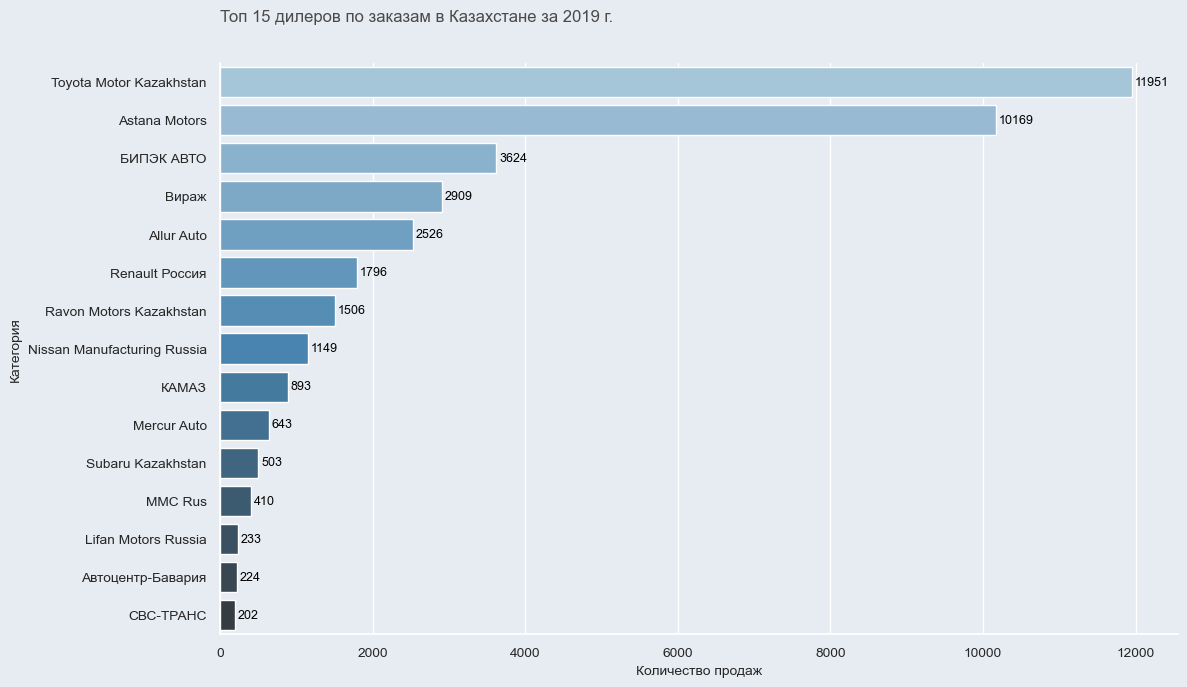

In [75]:
barplot_hor(df,'company','Топ 15 дилеров по заказам в Казахстане за 2019 г.')

In [76]:
styled_table(df.company,'Компания','Дилеры по количеству и долям заказов',vmax=14000,top_n=10)

Компания,Количество,Процент
Toyota Motor Kazakhstan,11951,30.03%
Astana Motors,10169,25.55%
БИПЭК АВТО,3624,9.11%
Вираж,2909,7.31%
Allur Auto,2526,6.35%
Renault Россия,1796,4.51%
Ravon Motors Kazakhstan,1506,3.78%
Nissan Manufacturing Russia,1149,2.89%
КАМАЗ,893,2.24%
Mercur Auto,643,1.62%


- Два дилера контролируют более половины рынка. Более 50% продаж приходятся на сети Toyota Motor Kazakhstan и Astana Motors.
- Компаня Mercur Auto замыкает десятку по количеству продаж.

-----

<a id='a3' a>

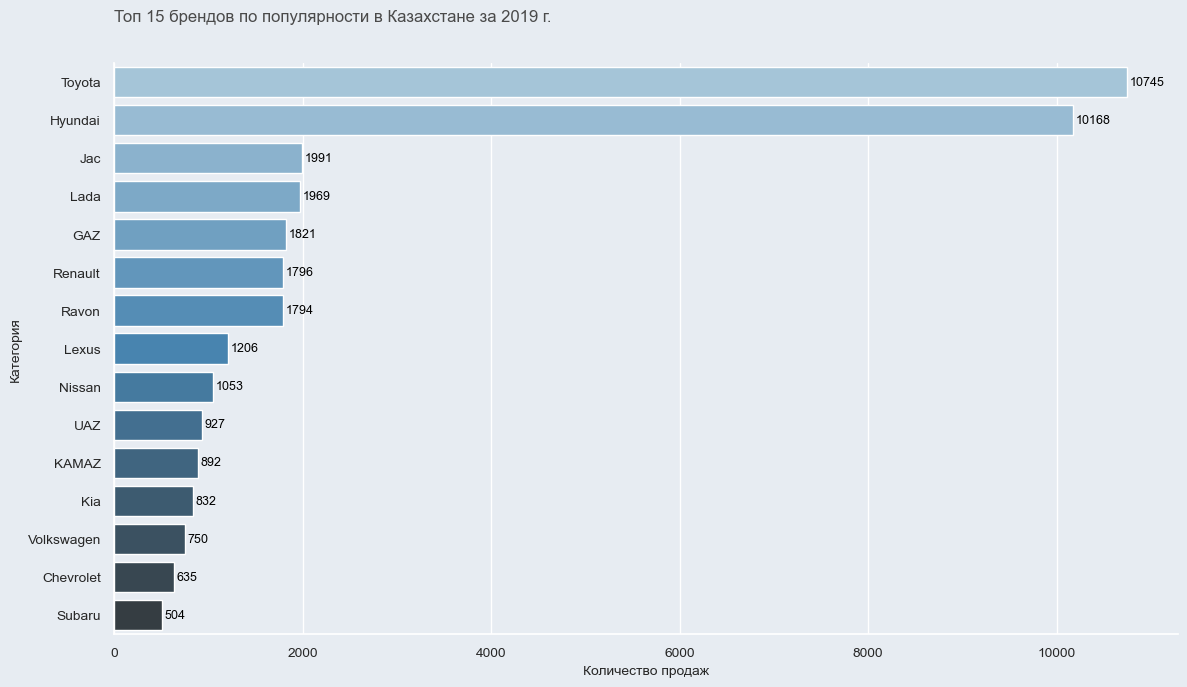

In [77]:
barplot_hor(df,'brand','Топ 15 брендов по популярности в Казахстане за 2019 г.')

In [78]:
styled_table(df.brand,'Бренд','Проданные машины по типу бренда',vmax=14000,top_n=10)

Бренд,Количество,Процент
Toyota,10745,26.89%
Hyundai,10168,25.44%
Jac,1991,4.98%
Lada,1969,4.93%
GAZ,1821,4.56%
Renault,1796,4.49%
Ravon,1794,4.49%
Lexus,1206,3.02%
Nissan,1053,2.63%
UAZ,927,2.32%


На рынке Казахстана в 2019 году лидировали бюджетные и среднеценовые бренды:

- Более 50% рынка и полное превосходство бренда Toyota и Hyundai
>- Toyota - 10 745 единиц (лидер по продажам)
>- Hyundai - 10 168 единиц (второе место)
- Китайский JAC и российские производители Lada и GAZ вошли в пятёрку.

Разрыв с третьим местом очень существнный,  говорит о доминировании Toyota и Hyundai на рынке.

----

<a id='a4' a>

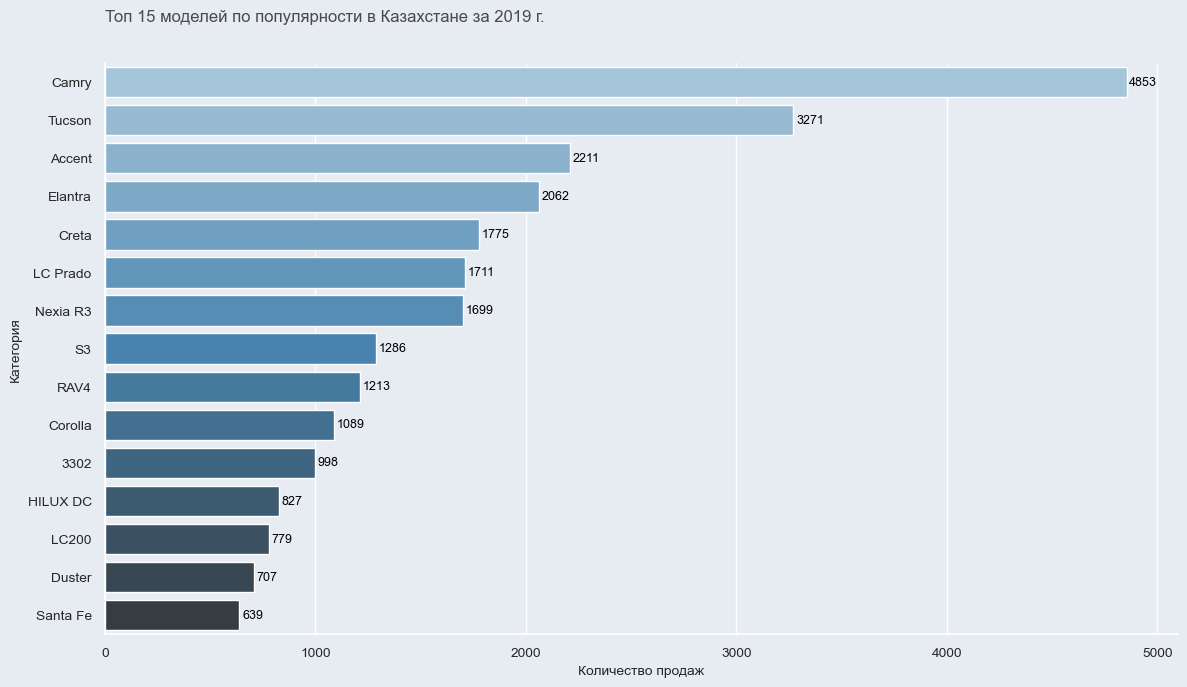

In [79]:
barplot_hor(df,'model','Топ 15 моделей по популярности в Казахстане за 2019 г.')

In [80]:
# Создаем сводную таблицу для пузырьковой диаграммы
pivot_df = df.pivot_table(
    index='model',
    values='price_usd',
    aggfunc=['mean', 'count']
).reset_index()
pivot_df.columns = ['model', 'mean_price', 'sales_count']
pivot_df = pivot_df.sort_values('sales_count',ascending=False).head(20)

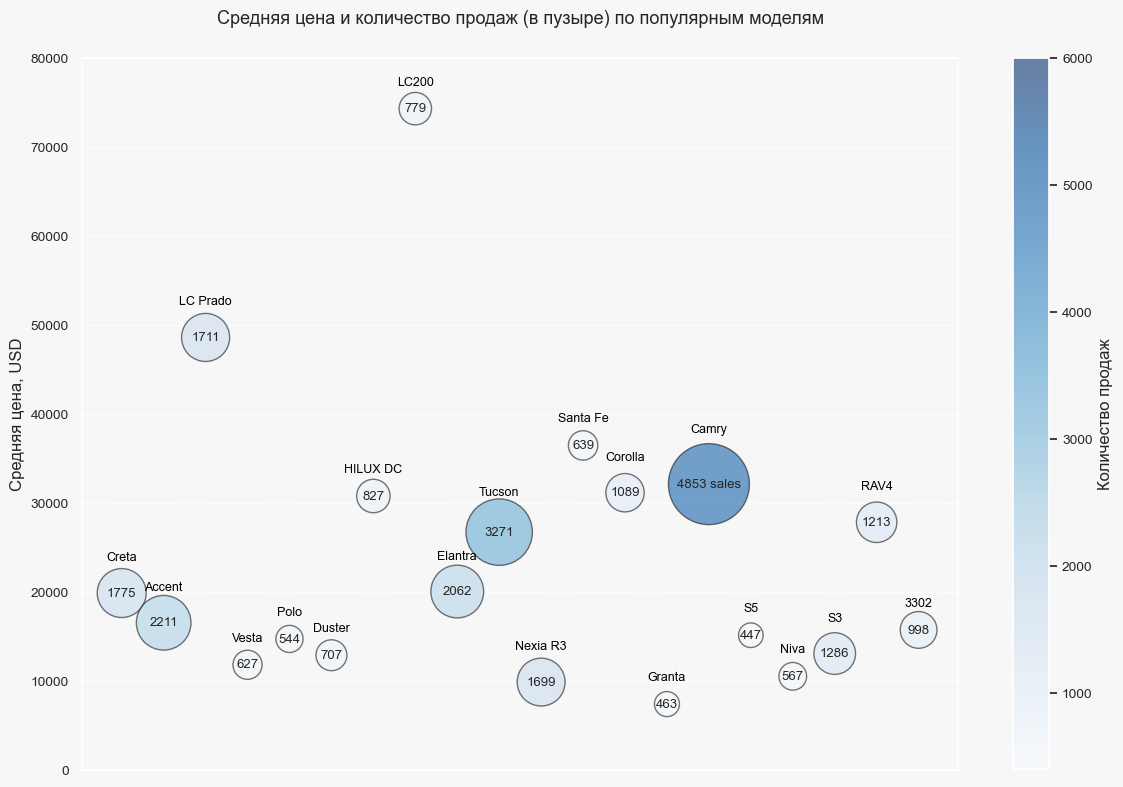

In [115]:
pivot_df_sorted = pivot_df.sample(20)

sns.set(rc={
    'axes.facecolor': '#f7f7f7',
    'figure.facecolor': '#f7f7f7',
    'font.family': 'Arial',
}, font_scale=0.9)

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    pivot_df_sorted['model'],
    pivot_df_sorted['mean_price'],
    s=pivot_df_sorted['sales_count']*0.7,  # размер пузыря
    alpha=0.6,
    c=pivot_df_sorted['sales_count'],
    cmap='Blues',
    edgecolors="k",
    vmin=400,
    vmax=6000
)

# Аннотации с количеством продаж в пузырь
for i, row in pivot_df_sorted.iterrows():
    sales_text = f"{int(row['sales_count'])} sales" if row['sales_count'] > 4000 else int(row['sales_count'])
    plt.text(
        row['model'],
        row['mean_price'],
        sales_text,
        ha='center',
        va='center',
        fontsize=9.5
    )

# Подписи моделей над пузырями
for i, row in pivot_df_sorted.iterrows():
    # Высота подписи в зависимости от sales_count
    if row['sales_count'] >= 4000:
        y_offset = row['mean_price'] + 5500 
        va = 'bottom'
    elif row['sales_count'] < 1000:
        y_offset = row['mean_price'] + 3000
        va = 'center'
    elif row['model'] == 'Tucson': 
        y_offset = row['mean_price'] + 4500
        va = 'center'
    else:
        y_offset = row['mean_price'] + 4000
        va = 'center'

    plt.text(
        x=row['model'],
        y=y_offset,
        s=row['model'],
        ha='center',
        va=va,
        fontsize=9,
        color='black'
    )

plt.title('Средняя цена и количество продаж (в пузыре) по популярным моделям', fontsize=13, pad=25)
plt.xlabel('')
plt.ylabel('Средняя цена, USD', fontsize=12)
plt.xticks([]) 
plt.grid(True, linestyle='--', alpha=1)
plt.ylim(0, 80000)
cbar = plt.colorbar(scatter)
cbar.set_label('Количество продаж', fontsize=12)

plt.tight_layout()
plt.show()

In [82]:
styled_table(df.model,'model','Проданные машины по типу модели',vmax=6000,top_n=10)

model,Количество,Процент
Camry,4853,12.14%
Tucson,3271,8.18%
Accent,2211,5.53%
Elantra,2062,5.16%
Creta,1775,4.44%
LC Prado,1711,4.28%
Nexia R3,1699,4.25%
S3,1286,3.22%
RAV4,1213,3.04%
Corolla,1089,2.72%


- Toyota Camry - абсолютный лидер и 4 853 заказов этого бренда. 
- Городской кроссовер Hyundai Tucson (3 271 ед.заказов) на втором месте и 8% всех заказов.
- Следующие три места занимают  бюджентные седаны марки Hundai: Elantra, Accnent и Creta. Это более 15% рынка.

Среди внедорожников выделились:

- Toyota Land Cruiser Prado (LC Prado) - 1 711(4.28%) флагман своего класса.
- Toyota Land Cruiser 200 (LC200) - 779 премиум модель и самая дорогая среди часто продаваемых автомобилей.

Среди отечественных моделей:

- Лада Granta - единственная часто продаваемая модель в категории до 10 тысяч долларов.
- Daewoo Nexia R3 - 1 699 ед., сохранила  высокий спрос видимо  благодаря доступности ,ремонтопригодности и западным технологиям.

Казахстан предпочитает надежные седаны Camry и  кроссоверы Tucson. Hyundai лидирует в массовом сегменте, Toyota – во внедорожном. Nexia сохраняет спрос как бюджетный вариант.

----

<a id='a5' a>

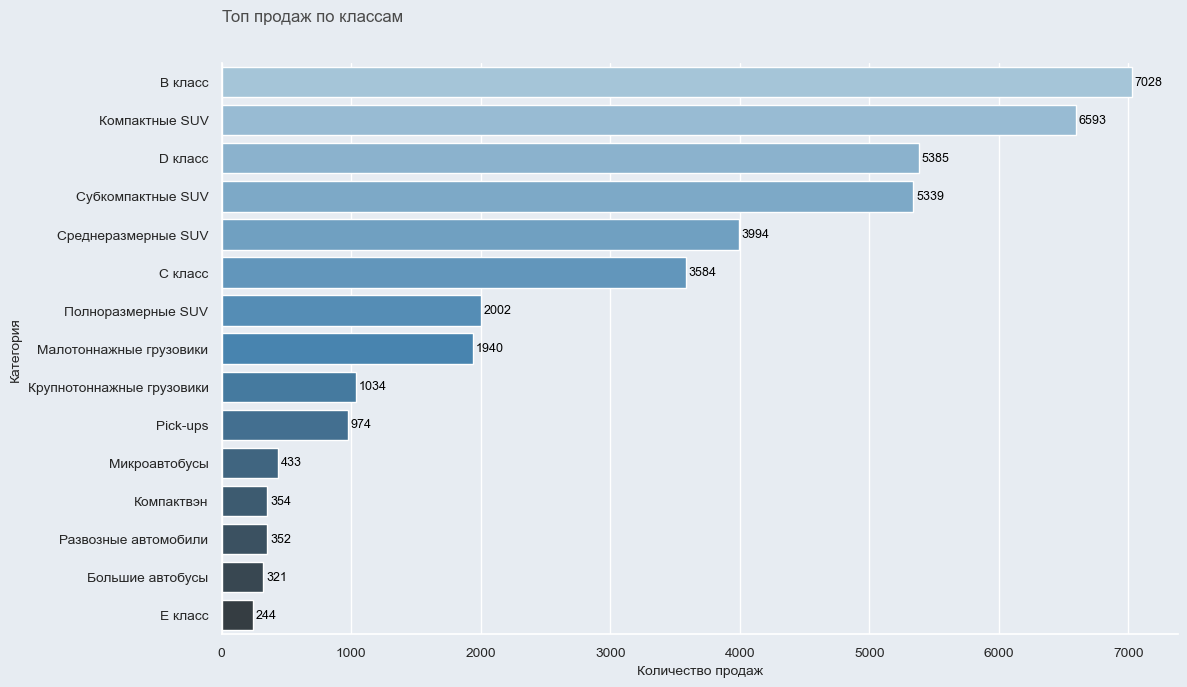

In [83]:
barplot_hor(df,'class_2013','Топ продаж по классам')

Вывод: Рынок ориентирован на практичные SUV и классические легковые, с явным перекосом в пользу универсальных городских моделей. Коммерческий сегмент развит умеренно, премиум - слабо.

----

<a id='a6' a>

In [84]:
styled_table(df.production_year,'Год выпуска','Проданные машины по году выпуска')

Год выпуска,Количество,Процент
2019,30026,76.08%
2018,9081,23.01%
2017,324,0.82%
2016,30,0.08%
2014,2,0.01%
2013,1,0.0%
2011,1,0.0%


Практические все машины выпускались в 2018 или 2019 годах.

-----

<a id='a7' a>

In [85]:
styled_table(df.country,'Место сборки','Авто по месту сборки', vmax=25000)

Место сборки,Количество,Процент
Республика Казахстан,19369,48.46%
Российская Федерация,12846,32.14%
Япония,4595,11.5%
Турция,1167,2.92%
Таиланд,970,2.43%
США,289,0.72%
Германия,265,0.66%
UK,197,0.49%
Китай,94,0.24%
Узбекистан,70,0.18%


- Локальное производство доминирует – почти 50% продаж приходятся на казахские авто.Скорее всего, это сборка в Казахстане, включая GAZ, Hyundai, Kia, Ravon и др.).
- Российские авто – вторые по популярности (32%), что объясняется географический близостью, совместным производством и дешевизной ключевых моделей адаптированных для внутреннего рынка.
- Японцы тртьи(11.5%) за счёт любви и доверии к марке camry. 

----

<a id='a8' a>

In [86]:
styled_table(df.area,'Область','Заказов по областям',vmax=12000)

Область,Количество,Процент
г.Алматы,11179,27.97%
г.Нур-Султан,8244,20.63%
Южно-Казахстанская область,2880,7.21%
Костанайская область,2494,6.24%
Атырауская область,2164,5.41%
Карагандинская область,2076,5.19%
Экспорт область,1810,4.53%
Мангистауская область,1495,3.74%
Западно-Казахстанская область,1493,3.74%
Восточно-Казахстанская область,1453,3.64%


- Алматы (27.9%) и Нур-Султан (20.6%) - почти 50% всех продаж.
- Средние регионы (5-7%): ЮКО, Костанай, Атырау, Караганда - суммарно 24%

На все остальные регионы приходится около 25% продаж соотвественно.

----

<a id='a9' a> 

### Анализ технических характеристик проданных авто

In [87]:
# Создадим новую переменную и категоризируем объёмы двигателей
df['engine_volume_type'] = df['engine_volume'].apply(
                                                  lambda x: 'Маленький' if x < 1.6 
                                                  else 'Средний' if 1.6 <= x <= 2.5 
                                                  else 'Большой'
)


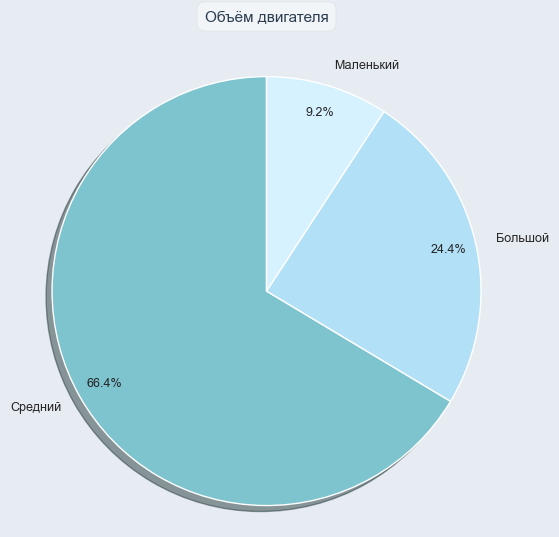

In [88]:
pie_chart(df.engine_volume_type,'Объём двигателя')

- Основной спрос(66.4%)  на двигатели 1.6–2.5л из-за популярности кроссоверов и седанов среднего класса.
- Двигатели объёмом более 2.5 (24.4%) – значительная доля, что  говорит о высоком спросе на внедорожники , коммерческие микроавтобусы и грузовики.
- Компактные городские малолитражки менее 1.6 литров наименее популярны. 

Несмотрян а то, что сегмент авто с объёмом до 1.6 уступает более мощным автомобилям, в среднесрочной перспективе его доля может увеличиться за счёт технологических и рыночных изменений,а также тренду на экологичность.

----

<a id='a11' a>

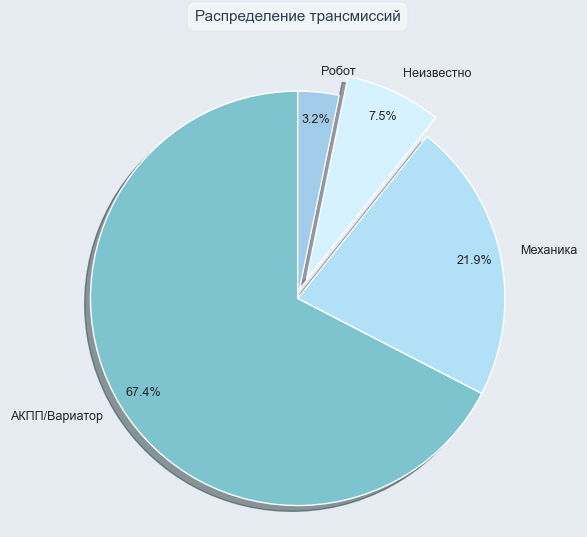

In [89]:
pie_chart(df.transmission,'Распределение трансмиссий',explode=(0,0,0.1,0.0))

2019 году казахстанский рынок уже был ориентирован на автоматические трансмиссии, а механика оставалась востребованной лишь в бюджетном сегменте. В будущем доля АКПП должна расти за счёт новых технологий и изменения предпочтений покупателей.

----

<a id='a12' a>

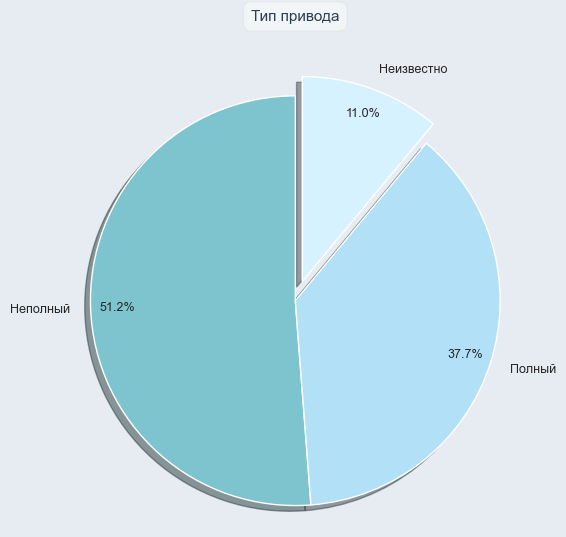

In [90]:
pie_chart(df.drive_type,'Тип привода',explode=(0,0,0.1))

Исходя из открытых источников, доля полноприводных машин, ежегодно прибавляет по одному проценту. Полный привод должен и дальше укреплять позиции на рынкк с учётом планов производителей по дальнейшему удешевлению и совершенствованию AWD-систем. Это соответствует общемировой тенденции, где разница в стоимости между приводами продолжает сокращаться, делая полноприводные версии доступнее для массового потребителя.

----

<a id='a13' a>

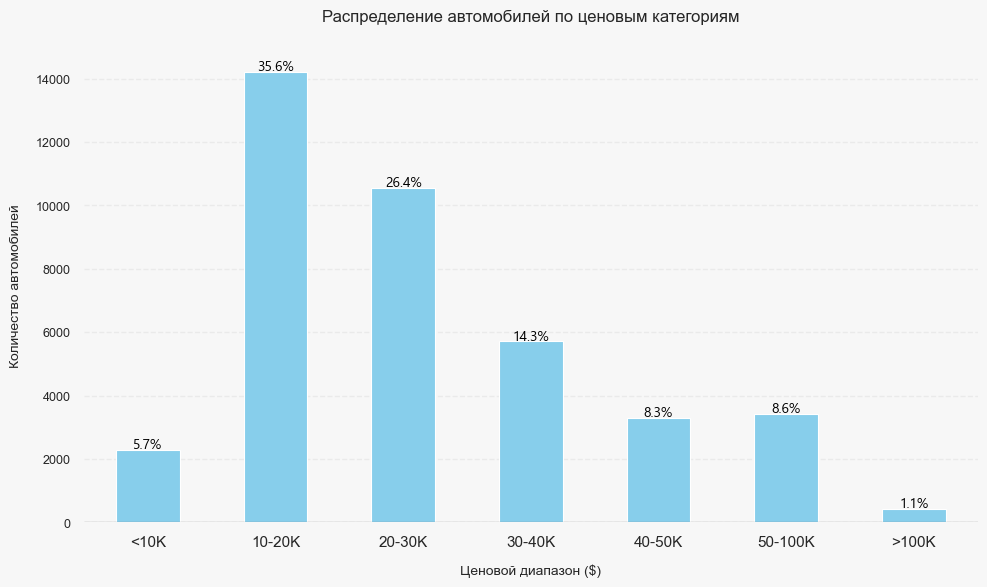

In [135]:
# Создаём ценовые категории
bins = [0, 10_000, 20_000, 30_000, 40_000, 50_000, 100_000, 200_000]
labels = ['<10K', '10-20K', '20-30K', '30-40K', '40-50K', '50-100K', '>100K']
df['price_range'] = pd.cut(df['price_usd'], bins=bins, labels=labels)

# Подсчёт и сортировка
value_counts = df['price_range'].value_counts().sort_index()
total = len(df)

# Построение
fig, ax = plt.subplots(figsize=(10, 6))
bars = value_counts.plot(kind='bar', ax=ax, color='skyblue', edgecolor='white', linewidth=0.8)

ax.set_title('Распределение автомобилей по ценовым категориям', pad=20, fontsize=12)
ax.set_xlabel('Ценовой диапазон ($)', labelpad=10, fontsize=10)
ax.set_ylabel('Количество автомобилей', labelpad=10, fontsize=10)

# Оформление
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.1, color='grey')
ax.grid(axis='x', linestyle=':', alpha=0.1)
sns.despine(left=True, bottom=True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(y=0, color='black', linewidth=0.8)

# Проценты над столбцами
for i, count in enumerate(value_counts):
    pct = f'{(count / total * 100):.1f}%'
    ax.text(i, count + total * 0.001, pct, ha='center', fontsize=10, color='black', fontfamily='Segoe UI')

plt.tight_layout()
plt.show()

- Доступные авто (10–30K) занимают большую часть(62%)  рынка. В этот сегмент попадают как наиболее популярные модели Hundai , так и Camry с минимальным пробегом. Доля этого сегмента должна оставаться стабильной и будет зависеть от состояния экономики государства.
- Премиум (30–100K ) сегмент автомобильного рынка КЗ  составил около 30%, что является отражением как благосостояние населения, так и развитой деловой активности в стране. Тут как Toyota Corolla, так и излюбленная Camry, чья средняя цена чуть выше 30000 USD.

-----

<a id ='a15' a>

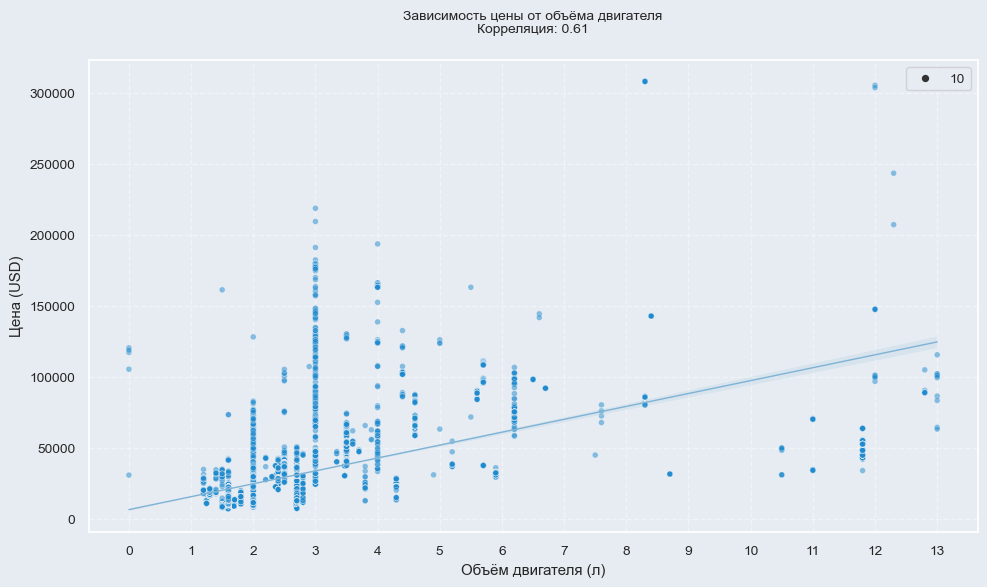

In [92]:
corr = df['engine_volume'].corr(df['price_usd'])
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='engine_volume', y='price_usd', alpha=0.5, color='#208ace',size=10)

sns.regplot(data=df, x='engine_volume', y='price_usd', scatter=False, color='#7FB3D5',
    line_kws={'linewidth': 1} )

plt.title(f'Зависимость цены от объёма двигателя\nКорреляция: {corr:.2f}',pad=20, size=10, loc='center')
plt.xlabel('Объём двигателя (л)')
plt.ylabel('Цена (USD)')
plt.xticks(range(0, 14))
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


Тут ничего удивительного. Мощность и технологичность двигетеля сильно коррелируют с ценой на авто.

<a id = 'a16' a>

#### Продажи автомобилей по месяцам

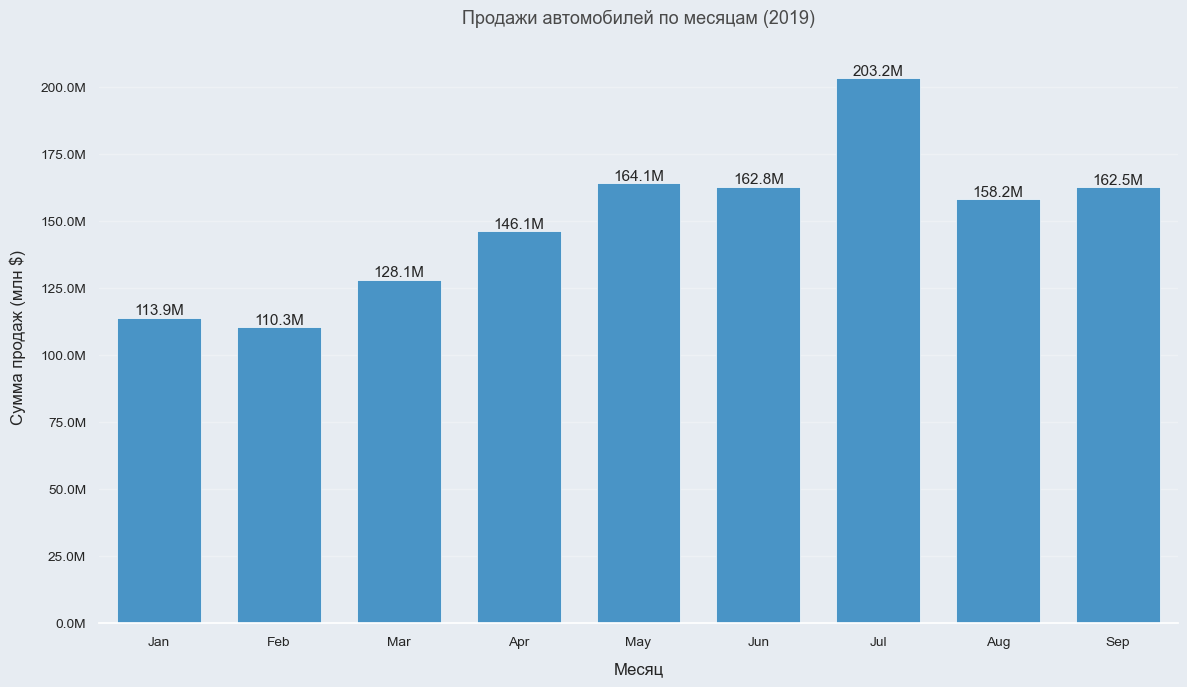

In [93]:
df_plot = df.copy()
df_plot['month'] = df_plot['sale_date'].dt.strftime('%b')  # Получаем названия месяцев 
monthly_sales = df_plot.groupby('month')['sales_usd'].sum().reset_index()

# Правильный порядок месяцев
monthly_sales['month'] = pd.Categorical(monthly_sales['month'], \
                                        categories=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'], \
                                        ordered=True)

monthly_sales = monthly_sales.sort_values('month')

# Создаем фигуру
plt.figure(figsize=(12, 7))

ax = sns.barplot( data=monthly_sales, x='month',  y='sales_usd', color='#3498db', edgecolor='white', width=0.7, linewidth=0.5)

plt.title('Продажи автомобилей по месяцам (2019)', 
          fontsize=13, pad=20, color='#4a4a4a')

plt.xlabel('Месяц', fontsize=12, labelpad=10)
plt.ylabel('Сумма продаж (млн $)', fontsize=12, labelpad=10)

# Форматирование оси Y
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

# Добавление значений на столбцы в миллионах
for p in ax.patches:
    ax.annotate(
        f"{p.get_height()/1e6:.1f}M", 
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='center', 
        xytext=(0, 5), 
        textcoords='offset points',
        fontsize=11
    )

# Сетка и границы
plt.grid(axis='y', alpha=0.3)
sns.despine(left=True)

plt.tight_layout()
plt.show()

- Лето объективно лучший период для продаж (июнь-июль).
- Январь и февраль – самые слабые месяцы возможно из-за дополнительный трат в новогодние праздники и кредитной паузы после Нового года.
- Рост с марта по июль ( рост около 80%) показывает сезонную активность покупателей.


<a id='a17' a>

## Анализ показателей дилерского центра "Mercur auto".

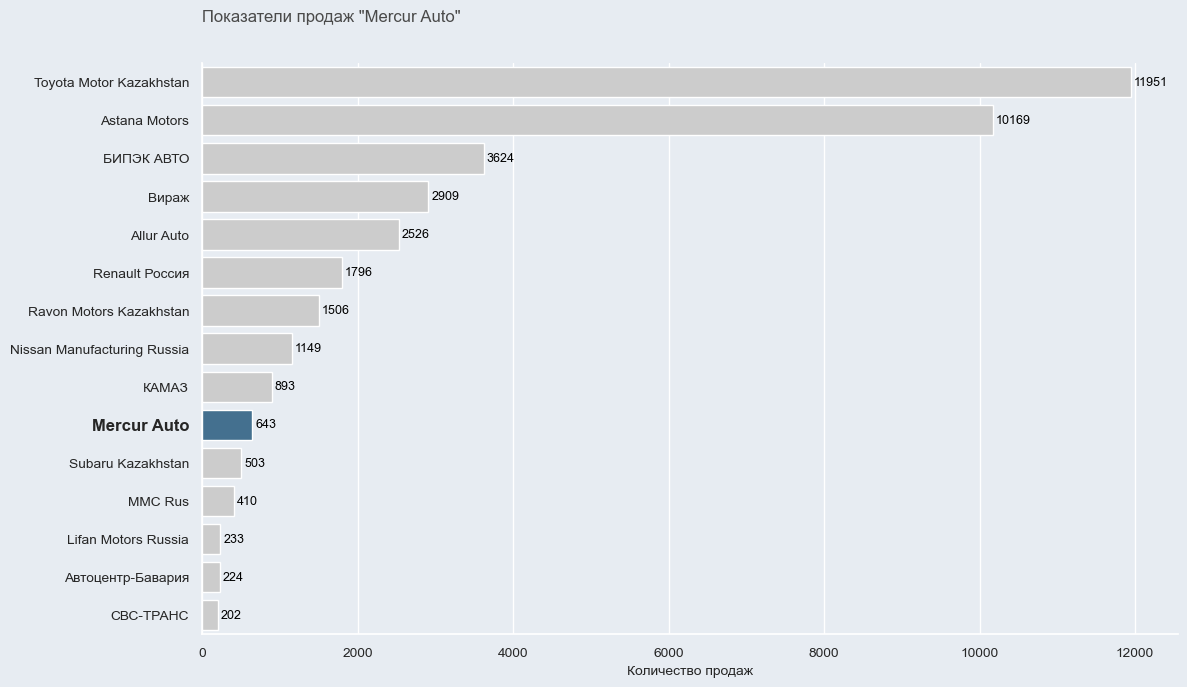

In [94]:
sns.set(rc={'axes.facecolor': '#e7ecf2', 'figure.facecolor': '#e7ecf2','font.family': 'Arial',}, font_scale=0.9)

# Получаем топ-15 категорий
top15 = df['company'].value_counts().head(15).reset_index()
top15.columns = ['category', 'count']

# Создаем цветовую палитру (Mercur Auto - синий, остальные - серые)
palette = ['#1f77b4' if cat == 'Mercur Auto' else '#CCCCCC95' for cat in top15['category']]

# график
plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top15, x='count', y='category', palette=palette,saturation=0.5)

# Заголовок и оси
ax.set_title('Показатели продаж "Mercur Auto"', size=12, pad=30, color='#4a4a4a', loc='left')
ax.set_xlabel('Количество продаж', fontsize=10)
ax.set_ylabel('')
# значения на барах
for i in ax.containers:
        ax.bar_label(
            i,
            label_type='edge',
            padding=2,
            fontsize=9,
            color='black'
        )
# выделяем Mercur Auto
for label in ax.get_yticklabels():
    if label.get_text() == 'Mercur Auto':
        label.set_fontweight('bold')
        label.set_fontsize(12)

sns.despine()
plt.tight_layout()
plt.show()

- Mercur Auto заняла 10-ую строчку в рейтинге автомобильных дилеров Казахстана, с 643-мя заказами.Как мы отмечали ранее, это около 1.5% всего рынка продаж.

In [95]:
# Создадим переменную для продаж Mercur auto 
mercury_df = df[df.company == 'Mercur Auto']

In [96]:
mercury_df = mercury_df.iloc[:,1:]

<a id='a18' a>

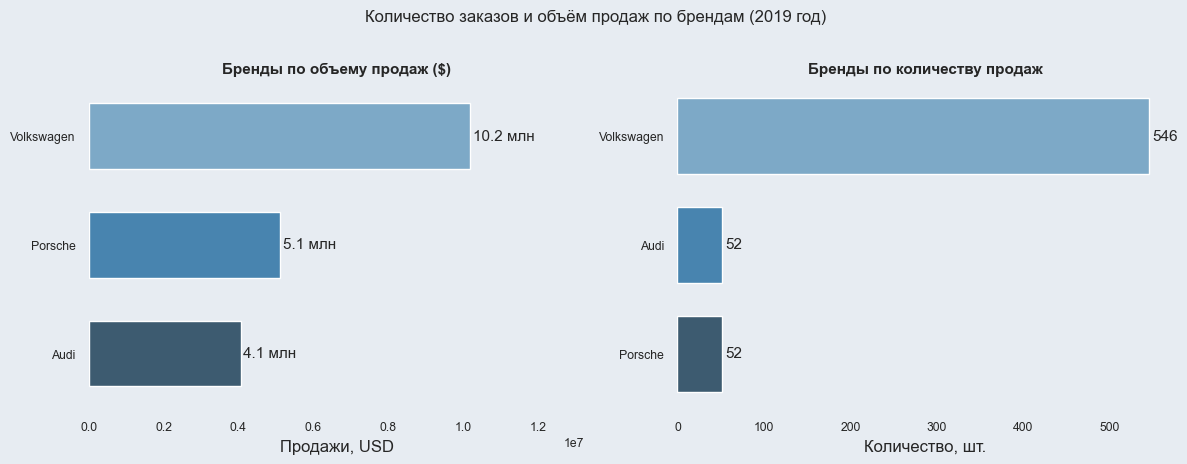

In [163]:
# Подготовка данных
brand_sales_value = mercury_df.groupby('brand')['sales_usd'].sum().sort_values(ascending=False).head(10).reset_index()
brand_sales_count = mercury_df.groupby('brand')['quantity'].sum().sort_values(ascending=False).head(10).reset_index()

# Настройки стиля
sns.set(rc={'axes.facecolor': '#e7ecf2', 'figure.facecolor': '#e7ecf2', 'font.family': 'Arial'}, font_scale=0.8)


fig, axes = plt.subplots(1, 2, figsize=(12, 4.5)) 
fig.suptitle('Количество заказов и объём продаж по брендам (2019 год)', fontsize=12, y=1.02)

#  Продажи по сумме 
ax1 = sns.barplot(data=brand_sales_value, x='sales_usd', y='brand',  width=0.6, palette='Blues_d', ax=axes[0])
ax1.set_title('Бренды по объему продаж ($)', fontsize=11)

ax1.bar_label(ax1.containers[0], 
              labels=[f'{val / 1_000_000:.1f} млн' for val in brand_sales_value['sales_usd']], 
              fontsize=11,padding=2)
ax1.grid(False)
ax1.set_xlabel('Продажи, USD', size= 12)
ax1.set_ylabel('')
sns.despine(ax=ax1, left=True, bottom=True)
xmax1 = brand_sales_value['sales_usd'].max() * 1.3
ax1.set_xlim(0, xmax1)


#  Продажи по количеству
ax2 = sns.barplot(data=brand_sales_count, x='quantity', y='brand', width=0.7, palette='Blues_d', ax=axes[1])
ax2.set_title('Бренды по количеству продаж', fontsize=11)
ax2.bar_label(ax2.containers[0], fontsize=11,padding=2)
ax2.set_xlabel('Количество, шт.', size=12)
ax2.set_ylabel('')
sns.despine(ax=ax2, left=True, bottom=True)
ax2.grid(False)

plt.tight_layout()
plt.show()

Дилерский центр Mercur Auto является представителем трёх автомобильных брендов: Audi, Porsche и Volkswagen.

- Volkswagen лидирует по объему продаж (546 авто)
- Машин марки Porsche продано в 10 раз меньше по сравнению с VW, при этом выручка составвляет всего половину от выручки от продаж VW.
- Porsche и Audi имеют значительно более высокую среднюю цену.
- Porsche как машины в основном премиум класса при 52 проданных авто, имеют выручку выше, чем у Audi  при равном количестве продаж.

<a id='a19' a>

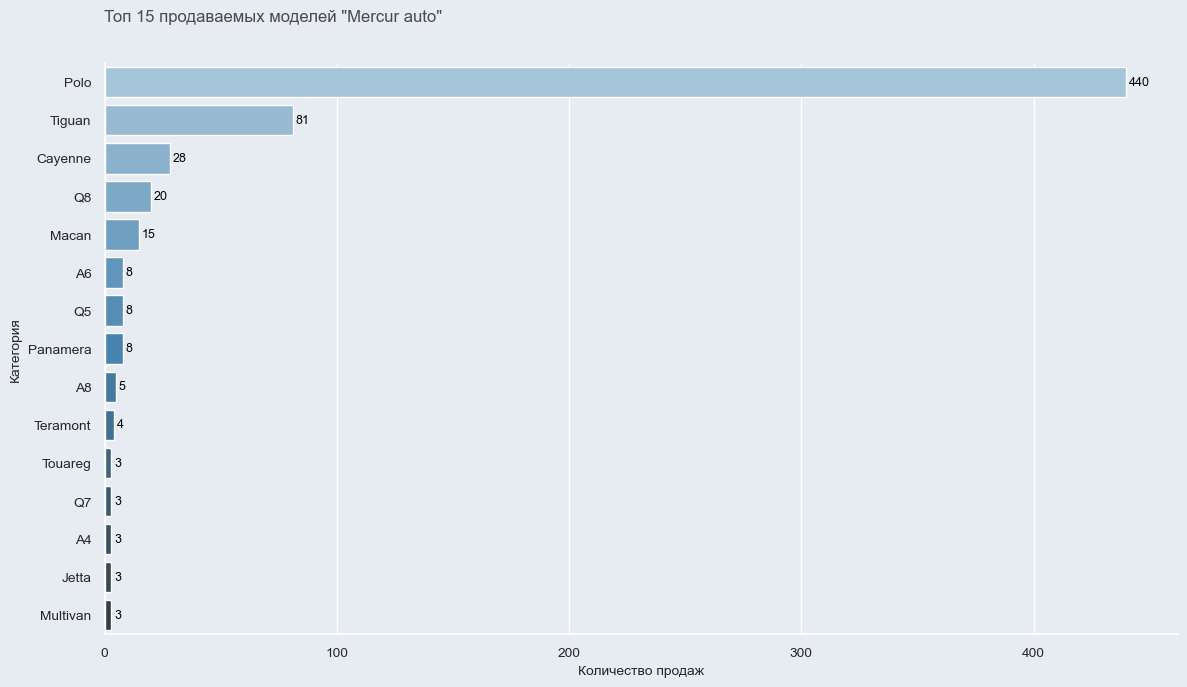

In [98]:
barplot_hor(mercury_df,'model','Топ 15 продаваемых моделей "Mercur auto"')

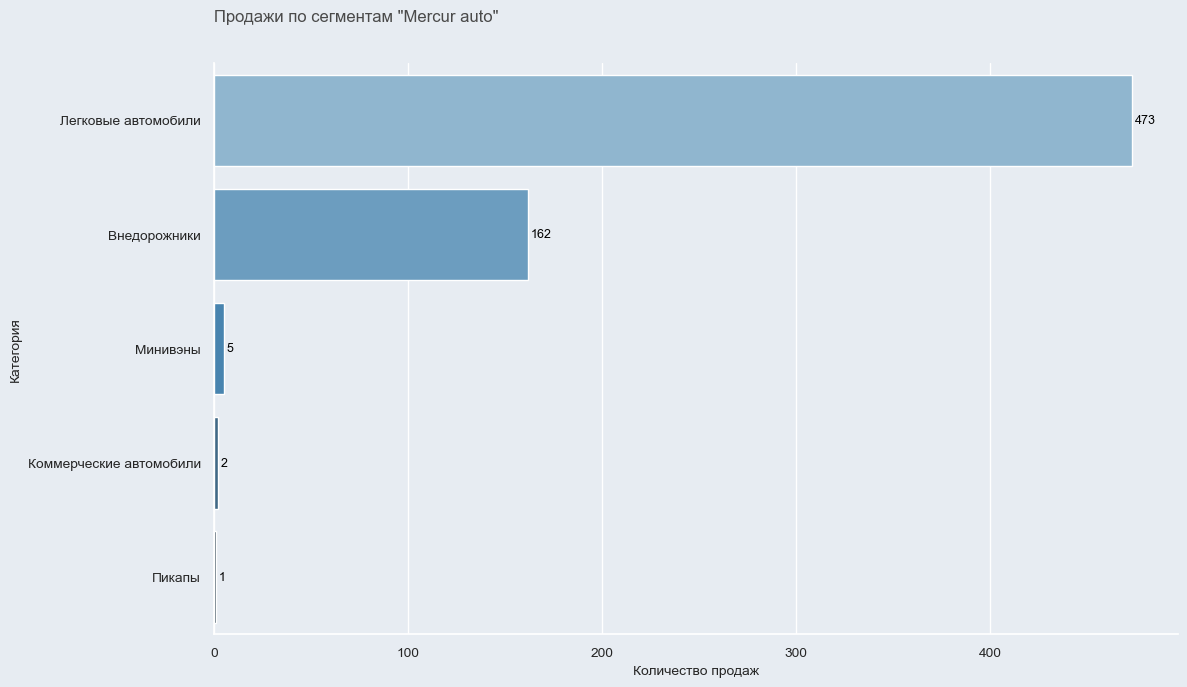

In [99]:
barplot_hor(mercury_df,'segment_2013','Продажи по сегментам "Mercur auto"')

**Категория: Легковые автомобили**

**Количество продаж: 473**
- Компания "Mercur auto" сильно зависит от продаж модели Polo, которая составляет значительную часть общего объёма продаж. Это требует внимания к стабильности поставок и ценовой политике этой модели.

**Категория: Внедорожники**

**Количество продаж: 162**
- Ассортимент внедорожников представлен среднеценовыми моделями (Tiguan), а также премиальными SUV (Q8, Cayenne, Macan, Touareg, Q7), которые составляют остальную часть продаж компании Mercur Auto.

**Примечание**
Компания Mercur Auto практически не осуществляет продажи коммерческого транспорта, включая минивэны и пикапы.

---

#### Динамика продаж по месяцам компании "Mercur auto"

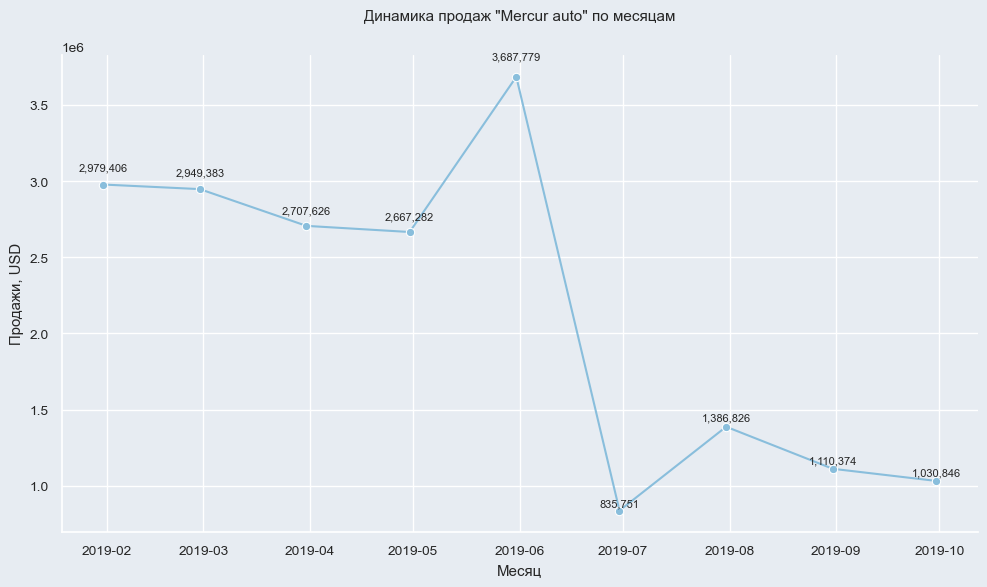

In [100]:
monthly_sales = mercury_df.groupby('sale_date')['sales_usd'].sum().reset_index()
sns.set(rc={
        'axes.facecolor': '#e7ecf2','figure.facecolor': '#e7ecf2','font.family': 'Arial',}, font_scale=0.9)

# График
plt.figure(figsize=(10, 6))
ax = sns.lineplot(data=monthly_sales, x='sale_date', y='sales_usd', marker='o', color=sns.color_palette("Blues")[2])

ax.set_title('Динамика продаж "Mercur auto" по месяцам', fontsize=11,pad=25)
ax.set_xlabel('Месяц')
ax.set_ylabel('Продажи, USD')

# подписи на граифке
for i in range(len(monthly_sales)):
    ax.text(monthly_sales['sale_date'][i], monthly_sales['sales_usd'][i] * 1.03,
            f"{int(monthly_sales['sales_usd'][i]):,}", ha='center', fontsize=8)

sns.despine()
plt.tight_layout()
plt.show()

- Июньское падение на с 3.7 млн до 835 тыс.(USD) - очень нетипично для активного сезона продаж,который отмечается на основном графике для всех компаний. 
- Продажи частично восстановленись в июле , но уровень в 2.5 раза ниже майского.
- Август-сентябрь: продажи остаются на 60-70% ниже условно докризисного уровня.

Такое критическое падение больше похоже на внешний сбой, чем естественное поведение рынка.Вероятно это связано с логистическим коллапсом или другими проблемами с импортом авто. Стоит рассмотреть более внимтельно и разбить на бренды.

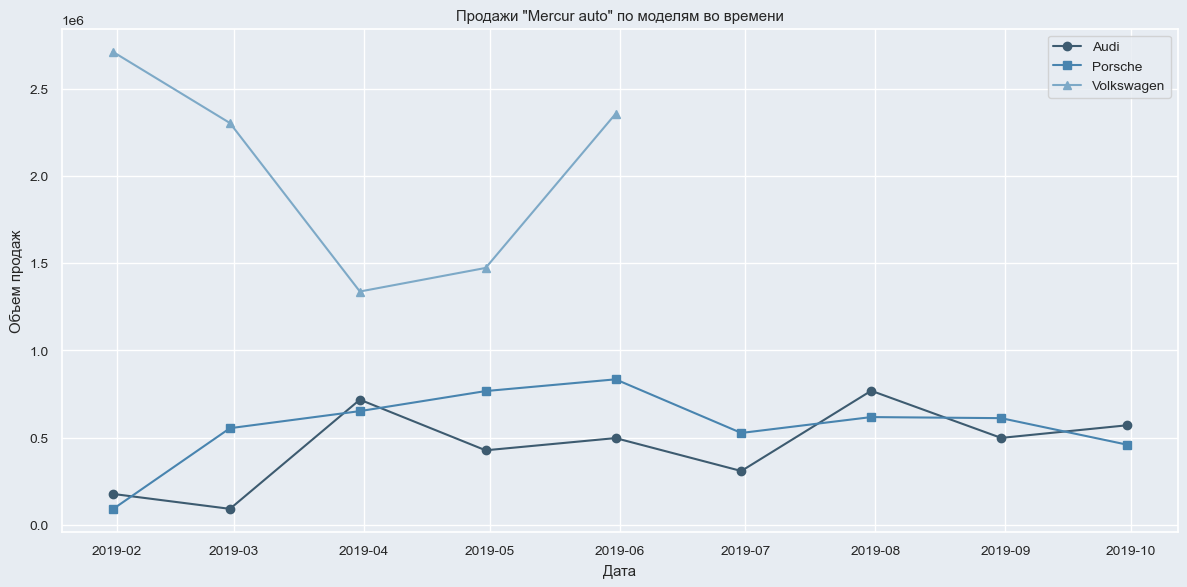

In [101]:
monthly_sales_brand = (mercury_df.pivot_table(index='sale_date',
                                              columns='brand',
                                              values='sales_usd',
                                              aggfunc='sum').reset_index())
# Строим график
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales_brand.sale_date, monthly_sales_brand['Audi'], label='Audi', marker='o', color='#3d5b70')
plt.plot(monthly_sales_brand.sale_date, monthly_sales_brand['Porsche'], label='Porsche', marker='s', color='#4884af')
plt.plot(monthly_sales_brand.sale_date, monthly_sales_brand['Volkswagen'], label='Volkswagen', marker='^',color='#7da9c7')

plt.title('Продажи "Mercur auto" по моделям во времени')
plt.xlabel('Дата')
plt.ylabel('Объем продаж')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Как показывают данные, основная доля продаж компании исторически формировалась за счёт реализации автомобилей марки Voltswagen. Резкий обвал продаж  VW в отчётном периоде, скорее всего, обусловлена аннулированием лицензии на его реализацию или другом правовым ограничением. Даже в случае прекращения поставок, дилерские центры продолжали бы реализацию складских остатков,и наблюдался бы постепенный (не моментальный) спад продаж.


### Общий вывод по анализу автомобильного рынка Казахстана за 2019 год
**1. Рынок и ключевые игроки**

На графиках заметно полное доминирование бюджетного и среднеценового сегмента:
- Для бренда Toyota более 10 745 заказов, у Hyundai их 10 168, и это чуть более 50% всего рынка.
- Toyota также лидирует во внедорожном сегменте (Land Cruiser Prado, LC200).
- Hyundai - в массовом сегменте (Tucson, Elantra, Accent, Creta), с долей заказов около 25%.
- Daewoo Nexia(~4.5%) сохраняет спрос как самый бюджетный вариант.
- Дилерские центры Toyota Motor Kazakhstan и Astana Motors контролируют более 55% рынка.
- Локальное производство (50% продаж) и российские бренды (32%) играют ключевую роль, что связано с географической близостью и адаптацией моделей под местный рынок.

**2. Популярные категории автомобилей**

`SUV(Спортивно-универсальные автомобили)`
- Кроссоверы Hyundai являются ключевым трендом на рынке. Среди популярных моделей выделяются Hyundai Tucson с долей продаж около 8% , Hyundai Creta — порядка 4,5% . 

`Бюджетные седаны:`
- Elantra, Accnent  - около 11% рынка.


`Внедорожники`
- Toyota Land Cruiser Prado единоличный лидер с долей около 4,2% 

`Седаны бизнес-класса:`
- Toyota Camry - абсолютный лидер 12% продаж(4 853 ед.), что подчеркивает спрос на комфорт и статус.

**3. Региональные особенности**

- Алматы и Нур-Султан обеспечивают почти 50% от общего объема продаж , что наглядно отражает высокую концентрацию покупательной способности в крупных городах страны.
- На Южно-Казахстанскую область приходится 7,21% продаж, 
- на Костанайскую область - 6,2% .

Все остальные регионы демонстрируют долю продаж на уровне 5% и ниже


**4. Технические предпочтения**

`Двигатели`
- Двигатели 1.6–2.5 л (66.4%): Тут и седаны бизнес класса и кроссоверы,как баланс мощности и экономичности.
- На маленький объём двигателя (до 1.6 литров) приходится всего 9 % продаж.
- Продажи двигателей объёмом более 2.5 литров составляют 24%. Это грузовики, автобусы и внедорожники.

`Коробки передач:`
- Около 70% автомобилей имеют автоматическую коробку передач или вариатор. 
- 21% приходится на механику. 
- Робот около 9%

`Тип привода:`

- Полный привод постепенно вытесняет неполный с 37% всех продаж
- 51% машин всё ещё имеют непольный тип привода. В основном это бюджетные седаны и небольшие комерческие грузовики.

**5. Ценовые сегменты**
- Средний сегмент (10-30K USD, 62% рынка). сновной спрос вокруг модельного рядов Hyundai и Toyota .
- Премиум (30–100K USD, 30%).
- На автомобили стоимостью менее 10K USD приходится менее 6 прцоентов продаж.

**6. Сезонность продаж**
Пик продаж летом (июнь-июль):
Рост на 80% с марта по июль связан с повышением покупательской активности.

Спад зимой (январь-февраль):
Вероятно связан с постпраздничными тратами и кредитной паузой.

----

### Анализ продаж компании ''Mercur Auto"

`Позиция на рынке:`
- Mercur Auto занимает 10-е место среди автомобильных дилеров Казахстана с долей около 1,5% рынка. Основу продаж составляют три бренда: Volkswagen (лидер по объёму), Audi и Porsche (премиум-сегмент с высокой маржинальностью).

`Структура продаж:`

- Volkswagen (546 авто) формирует основную выручку, но сильно зависит от модели Polo, что создаёт риски при изменении спроса или логистики.
- Porsche (52 авто) при малом количестве продаж обеспечивает значительную выручку благодаря высокой средней цене.
- Audi демонстрирует средние показатели, но уступает Porsche по прибыльности.
- Внедорожники: Продажи распределены между массовыми (Tiguan) и премиальными моделями (Cayenne, Q7 и др.).

`Кризисный период (июнь–сентябрь):`

- Резкое падение выручки в июне (с **3,7млн** USD до **835тыс.** USD) и последующее неполное восстановление указывают на внешний шок, а не естественный спад.

Вероятные причины: аннулирование лицензии VW (мгновенный обвал продаж исключает вариант постепенной распродажи остатков).

### Рекомендации:

Зависимость от Volkswagen (особенно Polo) делает компанию узвимой к поставкам или какм то правовом регулировании.В случае невозможностии продаж автомобилей марки Volkswagen, компании следует провести диверсификацию модельного ряда, сделав акцент на бюджетные модели, пользующиеся стабильным спросом в регионе.

`Стратегические приоритеты:`

**1.Срочная замена Volkswagen в линейке:**

- Переговоры с другими массовыми брендами (Toyota, Hyundai, возможно Kia) на поставки моделей-конкурентов Polo
- Анализ спроса на бюджетные SUV (например, Hyundai Creta) для замещения Tiguan.

**2.Ускоренная диверсификация:**

- Расширение сотрудничества с Audi (если контракт позволяет) по доступным моделям (A3, Q3),
- Увеличение маркетинговой поддержки премиум-направления (Porsche) для компенсации выручки.

**3.Работа с лояльностью клиентов:**

- Программы трейд-ин для владельцев VW, спецусловия на сервисное обслуживание.


Вывод: Mercur Auto необходимов срочном порядке переформатировать продуктовую матрицу, сделав ставку на альтернативные массовые бренды, пока пауза в продажах VW не привела к необратимой утрате клиентской базы. Премиум-сегмент не сможет компенсировать объёмы, но даст «подушку безопасности» для переходного периода.


[В начало](#a)